# Apply "Full" Random Forest Models to NH

Loads Maine Road Sample data set consisting of 110 damage locations

NH Road data set consists of 7 damage locations and 35 no-damage locations.

In [ ]:
# https://drive.google.com/file/d/1Q3nZD3b6yHmZkcsldsD8D8sF02uDrU6F/view?usp=sharing
!gdown 1Q3nZD3b6yHmZkcsldsD8D8sF02uDrU6F

Downloading...
From: https://drive.google.com/uc?id=1Q3nZD3b6yHmZkcsldsD8D8sF02uDrU6F
To: /content/ME_roads_all_info_with_structure.csv
100% 295k/295k [00:00<00:00, 89.3MB/s]


In [ ]:
import pandas as pd # Package for csvs and data
import numpy as np # Used for numerical and scientific computing
import joblib # Used for parallel computing, common in data science
from sklearn.compose import ColumnTransformer # Scikit-learn (sklearn) is a machine learning library, ColumnTransformer lets you apply different preprocessing steps to different types of columns
from sklearn.pipeline import Pipeline # Chains model steps into one workflow, described as an assembly line
from sklearn.preprocessing import OneHotEncoder # Converts categorical variables into binary indicators
from sklearn.impute import SimpleImputer # Handles missing values by replacing them with a specified strategy (mean, median, or most frequent)
from sklearn.ensemble import RandomForestClassifier # Imports the random forest modeling package
from sklearn.model_selection import train_test_split # Splits data sets into training and testing groups

# Load Maine data
df = pd.read_csv("ME_roads_all_info_with_structure.csv")

# Select the input features and target column (Damage_Status)
input_features = [
    'aadt_type', 'priority', 'capacity', 'Z_Min', 'Distance_to_Coast_m',
    'Max_WVHT', 'Max_Dir', 'Avg_WVHT', 'Avg_Dir',
    'Max_WSPD', 'Max_WSPD_Dir', 'Avg_WSPD', 'Avg_WSPD_Dir',
    'Precipitation', 'Rel_Elev_Min', 'Max_Height', 'Return_Period'
]
target_column = 'Damage_Status'

# Convert Damage/No-Damage lables to binary 0 and 1
df[target_column] = df[target_column].map({'No Damage': 0, 'Damage': 1})
df = df.dropna(subset=[target_column])

# Separate damage and no damage data frames
damage_df = df[df[target_column] == 1]
nodamage_df = df[df[target_column] == 0]

# Separate and identify the numerical and categorical columns correctly
numerical_cols = df[input_features].select_dtypes(include=np.number).columns  # selects all columns in input_features that are numeric
categorical_cols = df[input_features].select_dtypes(include='object').columns # selects all columns that are categorical

# Preprocessor: defines how to handle missing data and categorical encoding:
# Missing numbers ('num') replaced with mean of the column
# Missing categorical ('cat') values replaced with most frequent in column
# Onehot encoding is employed to category into binary columns
# This data set is not missing any data (most probably), this is to cover bases
preprocessor = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='mean'), numerical_cols),
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_cols)
    ],
    remainder='passthrough' # Keep other columns (like OBJECTID if not in input_features)
)

# Train Save 100 Models
n_runs = 100 # Number of runs

for run in range(n_runs):
    # 1:1 balanced sampling with each model trained on a different subset of the data
    nodamage_sample = nodamage_df.sample(n=len(damage_df), random_state=run)
    balanced_df = pd.concat([damage_df, nodamage_sample], axis=0)

    X = balanced_df[input_features] # input features
    y = balanced_df[target_column] # target columns (Damage_Status)

    # Splits data into 80% training and 20% testing
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=run
    )

    # Pipeline for the random forest
    pipeline = Pipeline(steps=[ # applies the preprocessing steps defined earlier
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(
            random_state=run, # Each hyperparameter below was honed using grid search, also meant to be relativel simple to limit overfitting
            n_estimators=400, # Number of trees used in the forest
            max_depth=3, # Depth each tree is limited to
            max_features='sqrt', # Each split considers a random subset of features equal to the sqrt of the total number of features
            bootstrap=True # Each tree is trained on a random sample with replacement
        ))
    ])

    # Fit and trains the models
    pipeline.fit(X_train, y_train)

    # Save model pipeline
    model_path = f"washout_model_run_{run}.pkl"
    joblib.dump(pipeline, model_path)

print(f"Done with {n_runs} models.") # Shows stuff is donw

Done with 100 models.


Load New Hampshire road data

In [ ]:
# https://drive.google.com/file/d/12Sy9VRseI1pKQn1VClXmQJC1ITir30Rb/view?usp=sharing
!gdown 12Sy9VRseI1pKQn1VClXmQJC1ITir30Rb

Downloading...
From: https://drive.google.com/uc?id=12Sy9VRseI1pKQn1VClXmQJC1ITir30Rb
To: /content/NH_roads_damage_sample.csv
100% 26.7k/26.7k [00:00<00:00, 45.9MB/s]


Apply the ensemble of RF models to the New Hampshire road data set

In [ ]:
import pandas as pd # Package for csvs and data
import numpy as np # Used for numerical and scientific computing
import joblib # Parallel computing, loads the models created in the previous cell
from sklearn.linear_model import LogisticRegression # Used for binary classification problems
from scipy.special import logit, expit  # Used to ge probabilities, one converts probabilities into log-odds, the other from log-odds to probabilities
from sklearn.model_selection import train_test_split # Splits data sets into training and testing groups

# Load Maine training data
me_df = pd.read_csv("ME_roads_all_info_with_structure.csv")

input_features = [
    'aadt_type', 'priority', 'capacity', 'Z_Min', 'Distance_to_Coast_m',
    'Max_WVHT', 'Max_Dir', 'Avg_WVHT', 'Avg_Dir',
    'Max_WSPD', 'Max_WSPD_Dir', 'Avg_WSPD', 'Avg_WSPD_Dir',
    'Precipitation', 'Rel_Elev_Min', 'Max_Height', 'Return_Period'
]
target_column = 'Damage_Status'

me_df[target_column] = me_df[target_column].map({'No Damage': 0, 'Damage': 1})
me_df = me_df.dropna(subset=[target_column])

X_me = me_df[input_features]
y_me = me_df[target_column]

# Load NH sample (7 damage and 35 no damage)
nh_df = pd.read_csv("NH_roads_damage_sample.csv")

# Align features, NH must use same input_features
nh_features = input_features
X_nh = nh_df[nh_features].copy()

# Load ensemble models (100 models)
n_models = 100
models = []
for run in range(n_models):
    try:
        model = joblib.load(f"washout_model_run_{run}.pkl")
        models.append(model)
    except:
        print(f"Warning: model washout_model_run_{run}.pkl not found, skipping")

if len(models) == 0:
    raise RuntimeError("No ensemble models loaded. Make sure the washout_model_run_*.pkl files exist.")

# Apply ensemble models to NH sample
all_probs = np.array([m.predict_proba(X_nh)[:,1] for m in models])  # shape (n_models, n_roads)

# Aggregate ensemble predictions
nh_df['p_mean_raw'] = all_probs.mean(axis=0)
nh_df['p_std'] = all_probs.std(axis=0)
nh_df['p_vote'] = (all_probs > 0.5).mean(axis=0)

# Scale predictions (Platt scaling using Maine data)
X_train, X_calib, y_train, y_calib = train_test_split(
    X_me, y_me, test_size=0.2, stratify=y_me, random_state=42
)

probs_calib = np.array([m.predict_proba(X_calib)[:,1] for m in models]).mean(axis=0)

platt = LogisticRegression()
platt.fit(probs_calib.reshape(-1,1), y_calib)

nh_df['p_mean_calib'] = platt.predict_proba(nh_df['p_mean_raw'].values.reshape(-1,1))[:,1]

# Prevalence adjustment
pi_train = 0.5      # training prevalence (1:1 damage to no damage)
pi_pop = 1/6   # 1 damage location and 5 no damage locations

logit_p = logit(nh_df['p_mean_calib'])
logit_p_adj = logit_p + (logit(pi_pop) - logit(pi_train))
nh_df['p_mean_adj'] = expit(logit_p_adj)

# Save results
nh_df.to_csv("NH_roads_sample_predictions.csv", index=False)
print("Saved to NH_roads_sample_predictions.csv (sample only)")

Saved to NH_roads_sample_predictions.csv (sample only)


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, cohen_kappa_score,
    precision_score, recall_score, f1_score, confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns

# Load NH sample results
nh_df = pd.read_csv("NH_roads_sample_predictions.csv")

# Change Damage_Status to numeric
nh_df['Damage_Status_num'] = nh_df['Damage_Status'].map({'No Damage': 0, 'Damage': 1})

# all_probs must match from Box 1 (stored in memory during same run)
# If running separately, you’d need to re-generate all_probs on the NH sample.
n_models = all_probs.shape[0]

# Loop through models to evaluate metrics
metrics_list = []
cms = []

for i in range(n_models):
    y_pred = (all_probs[i] > 0.5).astype(int)
    y_true = nh_df['Damage_Status_num'].values

    metrics_list.append({
        'accuracy': accuracy_score(y_true, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'cohen_kappa': cohen_kappa_score(y_true, y_pred),
        'precision_no_damage': precision_score(y_true, y_pred, pos_label=0, zero_division=0),
        'recall_no_damage': recall_score(y_true, y_pred, pos_label=0, zero_division=0),
        'f1_no_damage': f1_score(y_true, y_pred, pos_label=0, zero_division=0),
        'precision_damage': precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        'recall_damage': recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        'f1_damage': f1_score(y_true, y_pred, pos_label=1, zero_division=0)
    })

    cms.append(confusion_matrix(y_true, y_pred))

metrics_df = pd.DataFrame(metrics_list)
metrics_summary = metrics_df.agg(['mean', 'std']).T

print("NH Ensemble Model Performance")
print(metrics_summary)

# Confusion matrix summary
cms_array = np.stack(cms)
cm_mean = cms_array.mean(axis=0)
cm_std = cms_array.std(axis=0)

print("\nMean Confusion Matrix:\n", cm_mean.round(2))
print("\nStd Confusion Matrix:\n", cm_std.round(2))

NH Ensemble Model Performance
                         mean       std
accuracy             0.495952  0.105238
balanced_accuracy    0.511286  0.076818
cohen_kappa          0.014828  0.090486
precision_no_damage  0.839583  0.045887
recall_no_damage     0.488286  0.143525
f1_no_damage         0.605102  0.123939
precision_damage     0.176064  0.051605
recall_damage        0.534286  0.181180
f1_damage            0.259672  0.066697

Mean Confusion Matrix:
 [[17.09 17.91]
 [ 3.26  3.74]]

Std Confusion Matrix:
 [[5.   5.  ]
 [1.26 1.26]]


# Apply "Full" Random Forest Models to RI

Load RI data set, 60 damage and 300 no-damage locations

In [ ]:
# https://drive.google.com/file/d/1bVSQt2BtAnO0dp5IErx3_U0DIq7LILCs/view?usp=sharing
!gdown 1bVSQt2BtAnO0dp5IErx3_U0DIq7LILCs

Downloading...
From: https://drive.google.com/uc?id=1bVSQt2BtAnO0dp5IErx3_U0DIq7LILCs
To: /content/RI_roads_damage_sample.csv
100% 117k/117k [00:00<00:00, 58.6MB/s]


In [ ]:
import pandas as pd
import joblib
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Load Maine data
df = pd.read_csv("ME_roads_all_info_with_structure.csv")

# Keep only the shared features
input_features = [
    'Z_Min', 'Z_Max', 'Z_Mean', 'Min_Slope',
    'Max_Slope', 'Avg_Slope','Distance_to_Coast_m',
    'Max_Height', 'Rel_Elev_Min', 'Rel_Elev_Max','Rel_Elev_Mean'
]
target_column = 'Damage_Status'

# Change damage status to binary
df[target_column] = df[target_column].map({'No Damage': 0, 'Damage': 1})
df = df.dropna(subset=[target_column])

# Split into damage vs no damage
damage_df = df[df[target_column] == 1]
nodamage_df = df[df[target_column] == 0]

print(f"Maine data -> Damage: {len(damage_df)} | No Damage: {len(nodamage_df)}")

# Separate numerical and categorical columns
numerical_cols = df[input_features].select_dtypes(include=np.number).columns
categorical_cols = df[input_features].select_dtypes(include='object').columns

# Preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='mean'), numerical_cols),
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_cols)
    ],
    remainder='passthrough' # Keep other columns (like OBJECTID if not in input_features)
)

# Train models
n_runs = 100

for run in range(n_runs):
    # 1:1 balanced sampling
    nodamage_sample = nodamage_df.sample(n=len(damage_df), random_state=run)
    balanced_df = pd.concat([damage_df, nodamage_sample], axis=0)

    X = balanced_df[input_features]
    y = balanced_df[target_column]

    # Train/test split (just to mimic structure, models will be saved after training)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=run
    )

    # Pipeline with Random Forest
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(
            random_state=run,
            n_estimators=400,
            max_depth=3,
            max_features='sqrt',
            bootstrap=True
        ))
    ])

    # Fit
    pipeline.fit(X_train, y_train)

    # Save model
    model_path = f"washout_model_run_{run}.pkl"
    joblib.dump(pipeline, model_path)

print(f"Finished training and saving {n_runs} models.")

Maine data -> Damage: 110 | No Damage: 496
Finished training and saving 100 models.


In [ ]:
import pandas as pd
import numpy as np
import joblib
from sklearn.linear_model import LogisticRegression
from scipy.special import logit, expit  # for prevalence adjustment
from sklearn.model_selection import train_test_split

# Load Maine data, use same features
me_df = pd.read_csv("ME_roads_all_info_with_structure.csv")

input_features = [
    'Z_Min', 'Z_Max', 'Z_Mean', 'Min_Slope',
    'Max_Slope', 'Avg_Slope','Distance_to_Coast_m',
    'Max_Height', 'Rel_Elev_Min', 'Rel_Elev_Max','Rel_Elev_Mean'
]
target_column = 'Damage_Status'

me_df[target_column] = me_df[target_column].map({'No Damage': 0, 'Damage': 1})
me_df = me_df.dropna(subset=[target_column])

X_me = me_df[input_features]
y_me = me_df[target_column]

# Load RI data
ri_df = pd.read_csv("RI_roads_damage_sample.csv")

# Align features: RI only has subset, select overlapping numeric features
ri_features = input_features
X_ri = ri_df[ri_features].copy()

# Load models
n_models = 100
models = []
for run in range(n_models):
    try:
        model = joblib.load(f"washout_model_run_{run}.pkl")
        models.append(model)
    except:
        print(f"Warning: model washout_model_run_{run}.pkl not found, skipping")

if len(models) == 0:
    raise RuntimeError("No ensemble models loaded. Make sure the washout_model_run_*.pkl files exist.")

# Apply models to RI data
all_probs = np.array([m.predict_proba(X_ri)[:,1] for m in models])  # shape (n_models, n_roads)

# Aggregate ensemble predictions
ri_df['p_mean_raw'] = all_probs.mean(axis=0)
ri_df['p_std'] = all_probs.std(axis=0)
ri_df['p_vote'] = (all_probs > 0.5).mean(axis=0)  # fraction of models voting Damage

# Calibration step (Platt scaling using Maine data)
# Split Maine data into train/calibration
X_train, X_calib, y_train, y_calib = train_test_split(
    X_me, y_me, test_size=0.2, stratify=y_me, random_state=42
)

# Compute mean ensemble probabilities on Maine calibration set
probs_calib = np.array([m.predict_proba(X_calib)[:,1] for m in models]).mean(axis=0)

# Fit Platt scaling
platt = LogisticRegression()
platt.fit(probs_calib.reshape(-1,1), y_calib)

# Apply Platt calibration to RI ensemble probabilities
ri_df['p_mean_calib'] = platt.predict_proba(ri_df['p_mean_raw'].values.reshape(-1,1))[:,1]

# Prevalence adjustment
pi_train = 0.5      # training prevalence (1:1)
pi_pop = 1/6        # 1 damage to 5 damage

logit_p = logit(ri_df['p_mean_calib'])
logit_p_adj = logit_p + (logit(pi_pop) - logit(pi_train))
ri_df['p_mean_adj'] = expit(logit_p_adj)

# Save
ri_df.to_csv("RI_roads_predictions.csv", index=False)
print("Predictions with ensemble mean, calibration, and prevalence adjustment saved to RI_roads_predictions.csv")

Predictions with ensemble mean, calibration, and prevalence adjustment saved to RI_roads_predictions.csv


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, cohen_kappa_score,
    precision_score, recall_score, f1_score, confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns

# Map Damage_Status to numeric
ri_df['Damage_Status_num'] = ri_df['Damage_Status'].map({'No Damage': 0, 'Damage': 1})

# Initialize lists to store metrics per model
metrics_list = []
cms = []  # store confusion matrices

n_models = all_probs.shape[0]
y_true_ri = ri_df['Damage_Status_num'].values # Use true labels from RI data

for i in range(n_models):
    y_pred = (all_probs[i] > 0.5).astype(int)  # binary prediction per model for RI
    y_true = y_true_ri # Use RI true labels

    # Metrics
    metrics_list.append({
        'accuracy': accuracy_score(y_true, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'cohen_kappa': cohen_kappa_score(y_true, y_pred),
        'precision_no_damage': precision_score(y_true, y_pred, pos_label=0, zero_division=0),
        'recall_no_damage': recall_score(y_true, y_pred, pos_label=0, zero_division=0),
        'f1_no_damage': f1_score(y_true, y_pred, pos_label=0, zero_division=0),
        'precision_damage': precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        'recall_damage': recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        'f1_damage': f1_score(y_true, y_pred, pos_label=1, zero_division=0)
    })

    # Confusion matrix
    cms.append(confusion_matrix(y_true, y_pred))

# Convert to DataFrame
metrics_df = pd.DataFrame(metrics_list)

# Mean and std metrics
metrics_summary = metrics_df.agg(['mean', 'std']).T
print("RI Ensemble Model Performance Summary")
print(metrics_summary)

# Confusion matrix summary
cms_array = np.stack(cms)  # shape (n_models, 2, 2)
cm_mean = cms_array.mean(axis=0)
cm_std = cms_array.std(axis=0)

print("\nMean Confusion Matrix:\n", cm_mean.round(2))
print("\nStd Confusion Matrix:\n", cm_std.round(2))

RI Ensemble Model Performance Summary
                         mean       std
accuracy             0.544389  0.089832
balanced_accuracy    0.465633  0.015552
cohen_kappa         -0.043085  0.016287
precision_no_damage  0.814800  0.014749
recall_no_damage     0.583767  0.130453
f1_no_damage         0.671508  0.109712
precision_damage     0.143021  0.008496
recall_damage        0.347500  0.116928
f1_damage            0.198733  0.021098

Mean Confusion Matrix:
 [[175.13 124.87]
 [ 39.15  20.85]]

Std Confusion Matrix:
 [[38.94 38.94]
 [ 6.98  6.98]]


# Apply Three-Feature Random Forest Models to NH

Loads Maine Road Sample data set consisting of 110 damage locations

NH Road data set consists of 7 damage locations and 35 no-damage locations.

In [ ]:
# https://drive.google.com/file/d/1Q3nZD3b6yHmZkcsldsD8D8sF02uDrU6F/view?usp=sharing
!gdown 1Q3nZD3b6yHmZkcsldsD8D8sF02uDrU6F

Downloading...
From: https://drive.google.com/uc?id=1Q3nZD3b6yHmZkcsldsD8D8sF02uDrU6F
To: /content/ME_roads_all_info_with_structure.csv
100% 295k/295k [00:00<00:00, 79.8MB/s]


In [ ]:
import pandas as pd # Package for csvs and data
import numpy as np # Used for numerical and scientific computing
import joblib # Used for parallel computing, common in data science
from sklearn.compose import ColumnTransformer # Scikit-learn (sklearn) is a machine learning library, ColumnTransformer lets you apply different preprocessing steps to different types of columns
from sklearn.pipeline import Pipeline # Chains model steps into one workflow, described as an assembly line
from sklearn.preprocessing import OneHotEncoder # Converts categorical variables into binary indicators
from sklearn.impute import SimpleImputer # Handles missing values by replacing them with a specified strategy (mean, median, or most frequent)
from sklearn.ensemble import RandomForestClassifier # Imports the random forest modeling package
from sklearn.model_selection import train_test_split # Splits data sets into training and testing groups

# Load Maine data
df = pd.read_csv("ME_roads_all_info_with_structure.csv")

# Select the input features and target column (Damage_Status)
input_features = [
    'Z_Min', 'Distance_to_Coast_m','Rel_Elev_Min'
]
target_column = 'Damage_Status'

# Convert Damage/No-Damage lables to binary 0 and 1
df[target_column] = df[target_column].map({'No Damage': 0, 'Damage': 1})
df = df.dropna(subset=[target_column])

# Separate damage and no damage groups
damage_df = df[df[target_column] == 1]
nodamage_df = df[df[target_column] == 0]

# Separate and identify the numerical and categorical columns correctly
numerical_cols = df[input_features].select_dtypes(include=np.number).columns  # selects all columns in input_features that are numeric
categorical_cols = df[input_features].select_dtypes(include='object').columns # selects all columns that are categorical

# Preprocessor: defines how to handle missing data and categorical encoding:
# Missing numbers ('num') replaced with mean of the column
# Missing categorical ('cat') values replaced with most frequent in column
# Onehot encoding is employed to category into binary columns
# This data set is not missing any data (most probably), this is to cover bases
preprocessor = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='mean'), numerical_cols),
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_cols)
    ],
    remainder='passthrough' # Keep other columns (like OBJECTID if not in input_features)
)

# Train Save 100 Models
n_runs = 100 # Number of runs

for run in range(n_runs):
    # 1:1 balanced sampling with each model trained on a different subset of the data
    nodamage_sample = nodamage_df.sample(n=len(damage_df), random_state=run)
    balanced_df = pd.concat([damage_df, nodamage_sample], axis=0)

    X = balanced_df[input_features] # input features
    y = balanced_df[target_column] # target columns (Damage_Status)

    # Splits data into 80% training and 20% testing
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=run
    )

    # Pipeline for the random forest
    pipeline = Pipeline(steps=[ # applies the preprocessing steps defined earlier
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(
            random_state=run, # Each hyperparameter below was honed using grid search, also meant to be relativel simple to limit overfitting
            n_estimators=400, # Number of trees used in the forest
            max_depth=3, # Depth each tree is limited to
            max_features='sqrt', # Each split considers a random subset of features equal to the sqrt of the total number of features
            bootstrap=True # Each tree is trained on a random sample with replacement
        ))
    ])

    # Fit and trains the models
    pipeline.fit(X_train, y_train)

    # Save model pipeline
    model_path = f"washout_model_run_{run}.pkl"
    joblib.dump(pipeline, model_path)

print(f"Done with {n_runs} models.") # Shows stuff is donw

Done with 100 models.


Load New Hampshire road data

In [ ]:
# https://drive.google.com/file/d/12Sy9VRseI1pKQn1VClXmQJC1ITir30Rb/view?usp=sharing
!gdown 12Sy9VRseI1pKQn1VClXmQJC1ITir30Rb

Downloading...
From: https://drive.google.com/uc?id=12Sy9VRseI1pKQn1VClXmQJC1ITir30Rb
To: /content/NH_roads_damage_sample.csv
100% 26.7k/26.7k [00:00<00:00, 72.0MB/s]


Apply the ensemble of RF models to the New Hampshire road data set

In [ ]:
import pandas as pd # Package for csvs and data
import numpy as np # Used for numerical and scientific computing
import joblib # Parallel computing, loads the models created in the previous cell
from sklearn.linear_model import LogisticRegression # Used for binary classification problems
from scipy.special import logit, expit  # Used to ge probabilities, one converts probabilities into log-odds, the other from log-odds to probabilities
from sklearn.model_selection import train_test_split # Splits data sets into training and testing groups

# Load Maine training data
me_df = pd.read_csv("ME_roads_all_info_with_structure.csv")

input_features = [
    'Z_Min', 'Distance_to_Coast_m','Rel_Elev_Min'
]
target_column = 'Damage_Status'

me_df[target_column] = me_df[target_column].map({'No Damage': 0, 'Damage': 1})
me_df = me_df.dropna(subset=[target_column])

X_me = me_df[input_features]
y_me = me_df[target_column]

# Load NH sample (7 damage and 35 no damage)
nh_df = pd.read_csv("NH_roads_damage_sample.csv")

# Align features, NH must use same input_features
nh_features = input_features
X_nh = nh_df[nh_features].copy()

# Load ensemble models (100 models)
n_models = 100
models = []
for run in range(n_models):
    try:
        model = joblib.load(f"washout_model_run_{run}.pkl")
        models.append(model)
    except:
        print(f"Warning: model washout_model_run_{run}.pkl not found, skipping")

if len(models) == 0:
    raise RuntimeError("No ensemble models loaded. Make sure the washout_model_run_*.pkl files exist.")

# Apply ensemble models to NH sample
all_probs = np.array([m.predict_proba(X_nh)[:,1] for m in models])  # shape (n_models, n_roads)

# Aggregate ensemble predictions
nh_df['p_mean_raw'] = all_probs.mean(axis=0)
nh_df['p_std'] = all_probs.std(axis=0)
nh_df['p_vote'] = (all_probs > 0.5).mean(axis=0)

# Scale predictions (Platt scaling using Maine data)
X_train, X_calib, y_train, y_calib = train_test_split(
    X_me, y_me, test_size=0.2, stratify=y_me, random_state=42
)

probs_calib = np.array([m.predict_proba(X_calib)[:,1] for m in models]).mean(axis=0)

platt = LogisticRegression()
platt.fit(probs_calib.reshape(-1,1), y_calib)

nh_df['p_mean_calib'] = platt.predict_proba(nh_df['p_mean_raw'].values.reshape(-1,1))[:,1]

# Prevalence adjustment
pi_train = 0.5      # training prevalence (1:1 damage to no damage)
pi_pop = 1/6   # 1 damage location and 5 no damage locations

logit_p = logit(nh_df['p_mean_calib'])
logit_p_adj = logit_p + (logit(pi_pop) - logit(pi_train))
nh_df['p_mean_adj'] = expit(logit_p_adj)

# Save results
nh_df.to_csv("NH_roads_sample_predictions.csv", index=False)
print("Saved to NH_roads_sample_predictions.csv (sample only)")

Saved to NH_roads_sample_predictions.csv (sample only)


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, cohen_kappa_score,
    precision_score, recall_score, f1_score, confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns

# Load NH sample results
nh_df = pd.read_csv("NH_roads_sample_predictions.csv")

# Change Damage_Status to numeric
nh_df['Damage_Status_num'] = nh_df['Damage_Status'].map({'No Damage': 0, 'Damage': 1})

# all_probs must match from Box 1 (stored in memory during same run)
# If running separately, you’d need to re-generate all_probs on the NH sample.
n_models = all_probs.shape[0]

# Loop through models to evaluate metrics
metrics_list = []
cms = []

for i in range(n_models):
    y_pred = (all_probs[i] > 0.5).astype(int)
    y_true = nh_df['Damage_Status_num'].values

    metrics_list.append({
        'accuracy': accuracy_score(y_true, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'cohen_kappa': cohen_kappa_score(y_true, y_pred),
        'precision_no_damage': precision_score(y_true, y_pred, pos_label=0, zero_division=0),
        'recall_no_damage': recall_score(y_true, y_pred, pos_label=0, zero_division=0),
        'f1_no_damage': f1_score(y_true, y_pred, pos_label=0, zero_division=0),
        'precision_damage': precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        'recall_damage': recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        'f1_damage': f1_score(y_true, y_pred, pos_label=1, zero_division=0)
    })

    cms.append(confusion_matrix(y_true, y_pred))

metrics_df = pd.DataFrame(metrics_list)
metrics_summary = metrics_df.agg(['mean', 'std']).T

print("NH Ensemble Model Performance")
print(metrics_summary)

# Confusion matrix summary
cms_array = np.stack(cms)
cm_mean = cms_array.mean(axis=0)
cm_std = cms_array.std(axis=0)

print("\nMean Confusion Matrix:\n", cm_mean.round(2))
print("\nStd Confusion Matrix:\n", cm_std.round(2))

NH Ensemble Model Performance
                         mean       std
accuracy             0.365000  0.071313
balanced_accuracy    0.547571  0.057826
cohen_kappa          0.041822  0.052752
precision_no_damage  0.885018  0.061411
recall_no_damage     0.273714  0.088430
f1_no_damage         0.411040  0.100751
precision_damage     0.185694  0.024390
recall_damage        0.821429  0.100247
f1_damage            0.302298  0.036370

Mean Confusion Matrix:
 [[ 9.58 25.42]
 [ 1.25  5.75]]

Std Confusion Matrix:
 [[3.08 3.08]
 [0.7  0.7 ]]


# Apply Three-Feature Random Forest Models to RI

Load RI data set, 60 damage and 300 no-damage locations

In [ ]:
# https://drive.google.com/file/d/1bVSQt2BtAnO0dp5IErx3_U0DIq7LILCs/view?usp=sharing
!gdown 1bVSQt2BtAnO0dp5IErx3_U0DIq7LILCs

Downloading...
From: https://drive.google.com/uc?id=1bVSQt2BtAnO0dp5IErx3_U0DIq7LILCs
To: /content/RI_roads_damage_sample.csv
100% 117k/117k [00:00<00:00, 90.7MB/s]


In [ ]:
import pandas as pd
import joblib
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Load Maine data
df = pd.read_csv("ME_roads_all_info_with_structure.csv")

# Keep only the shared features
input_features = [
    'Z_Min', 'Distance_to_Coast_m','Rel_Elev_Min'
]
target_column = 'Damage_Status'

# Change damage status to binary
df[target_column] = df[target_column].map({'No Damage': 0, 'Damage': 1})
df = df.dropna(subset=[target_column])

# Split into damage vs no damage
damage_df = df[df[target_column] == 1]
nodamage_df = df[df[target_column] == 0]

print(f"Maine data -> Damage: {len(damage_df)} | No Damage: {len(nodamage_df)}")

# Separate numerical and categorical columns
numerical_cols = df[input_features].select_dtypes(include=np.number).columns
categorical_cols = df[input_features].select_dtypes(include='object').columns

# Preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='mean'), numerical_cols),
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_cols)
    ],
    remainder='passthrough' # Keep other columns (like OBJECTID if not in input_features)
)

# Train models
n_runs = 100

for run in range(n_runs):
    # 1:1 balanced sampling
    nodamage_sample = nodamage_df.sample(n=len(damage_df), random_state=run)
    balanced_df = pd.concat([damage_df, nodamage_sample], axis=0)

    X = balanced_df[input_features]
    y = balanced_df[target_column]

    # Train/test split (just to mimic structure, models will be saved after training)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=run
    )

    # Pipeline with Random Forest
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(
            random_state=run,
            n_estimators=400,
            max_depth=3,
            max_features='sqrt',
            bootstrap=True
        ))
    ])

    # Fit
    pipeline.fit(X_train, y_train)

    # Save model
    model_path = f"washout_model_run_{run}.pkl"
    joblib.dump(pipeline, model_path)

print(f"Finished training and saving {n_runs} models.")

Maine data -> Damage: 110 | No Damage: 496
Finished training and saving 100 models.


In [ ]:
import pandas as pd
import numpy as np
import joblib
from sklearn.linear_model import LogisticRegression
from scipy.special import logit, expit  # for prevalence adjustment
from sklearn.model_selection import train_test_split

# Load Maine data, use same features
me_df = pd.read_csv("ME_roads_all_info_with_structure.csv")

input_features = [
    'Z_Min', 'Distance_to_Coast_m','Rel_Elev_Min'
]
target_column = 'Damage_Status'

me_df[target_column] = me_df[target_column].map({'No Damage': 0, 'Damage': 1})
me_df = me_df.dropna(subset=[target_column])

X_me = me_df[input_features]
y_me = me_df[target_column]

# Load RI data
ri_df = pd.read_csv("RI_roads_damage_sample.csv")

# Align features: RI only has subset, select overlapping numeric features
ri_features = input_features
X_ri = ri_df[ri_features].copy()

# Load models
n_models = 100
models = []
for run in range(n_models):
    try:
        model = joblib.load(f"washout_model_run_{run}.pkl")
        models.append(model)
    except:
        print(f"Warning: model washout_model_run_{run}.pkl not found")

if len(models) == 0:
    raise RuntimeError("No ensemble models loaded. Make sure the washout_model_run_*.pkl files exist.")

# Apply models to RI data
all_probs = np.array([m.predict_proba(X_ri)[:,1] for m in models])  # shape (n_models, n_roads)

# Aggregate ensemble predictions
ri_df['p_mean_raw'] = all_probs.mean(axis=0)
ri_df['p_std'] = all_probs.std(axis=0)
ri_df['p_vote'] = (all_probs > 0.5).mean(axis=0)  # fraction of models voting Damage

# Calibration step (Platt scaling using Maine data)
# Split Maine data into train/calibration
X_train, X_calib, y_train, y_calib = train_test_split(
    X_me, y_me, test_size=0.2, stratify=y_me, random_state=42
)

# Compute mean ensemble probabilities on Maine calibration set
probs_calib = np.array([m.predict_proba(X_calib)[:,1] for m in models]).mean(axis=0)

# Fit Platt scaling
platt = LogisticRegression()
platt.fit(probs_calib.reshape(-1,1), y_calib)

# Apply Platt calibration to RI ensemble probabilities
ri_df['p_mean_calib'] = platt.predict_proba(ri_df['p_mean_raw'].values.reshape(-1,1))[:,1]

# Prevalence adjustment
pi_train = 0.5      # training prevalence (1:1)
pi_pop = 1/6        # 1 damage to 5 damage

logit_p = logit(ri_df['p_mean_calib'])
logit_p_adj = logit_p + (logit(pi_pop) - logit(pi_train))
ri_df['p_mean_adj'] = expit(logit_p_adj)

# Save
ri_df.to_csv("RI_roads_predictions.csv", index=False)
print("Predictions with ensemble mean, calibration, and prevalence adjustment saved to RI_roads_predictions.csv")

Predictions with ensemble mean, calibration, and prevalence adjustment saved to RI_roads_predictions.csv


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, cohen_kappa_score,
    precision_score, recall_score, f1_score, confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns

# Map Damage_Status to numeric
ri_df['Damage_Status_num'] = ri_df['Damage_Status'].map({'No Damage': 0, 'Damage': 1})

# Initialize lists to store metrics per model
metrics_list = []
cms = []  # store confusion matrices

n_models = all_probs.shape[0]
y_true_ri = ri_df['Damage_Status_num'].values # Use true labels from RI data

for i in range(n_models):
    y_pred = (all_probs[i] > 0.5).astype(int)  # binary prediction per model for RI
    y_true = y_true_ri # Use RI true labels

    # Metrics
    metrics_list.append({
        'accuracy': accuracy_score(y_true, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'cohen_kappa': cohen_kappa_score(y_true, y_pred),
        'precision_no_damage': precision_score(y_true, y_pred, pos_label=0, zero_division=0),
        'recall_no_damage': recall_score(y_true, y_pred, pos_label=0, zero_division=0),
        'f1_no_damage': f1_score(y_true, y_pred, pos_label=0, zero_division=0),
        'precision_damage': precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        'recall_damage': recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        'f1_damage': f1_score(y_true, y_pred, pos_label=1, zero_division=0)
    })

    # Confusion matrix
    cms.append(confusion_matrix(y_true, y_pred))

# Convert to DataFrame
metrics_df = pd.DataFrame(metrics_list)

# Mean and std metrics
metrics_summary = metrics_df.agg(['mean', 'std']).T
print("RI Ensemble Model Performance Summary")
print(metrics_summary)

# Confusion matrix summary
cms_array = np.stack(cms)  # shape (n_models, 2, 2)
cm_mean = cms_array.mean(axis=0)
cm_std = cms_array.std(axis=0)

print("\nMean Confusion Matrix:\n", cm_mean.round(2))
print("\nStd Confusion Matrix:\n", cm_std.round(2))

RI Ensemble Model Performance Summary
                         mean       std
accuracy             0.686194  0.028166
balanced_accuracy    0.496850  0.009738
cohen_kappa         -0.005069  0.017466
precision_no_damage  0.832130  0.003529
recall_no_damage     0.780867  0.039522
f1_no_damage         0.805216  0.022092
precision_damage     0.163344  0.013260
recall_damage        0.212833  0.033823
f1_damage            0.183456  0.017199

Mean Confusion Matrix:
 [[234.26  65.74]
 [ 47.23  12.77]]

Std Confusion Matrix:
 [[11.8  11.8 ]
 [ 2.02  2.02]]


# Simple Dec Tree Apply to NH (1:5 Ratio)

In [ ]:
import pandas as pd
import joblib
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

# Load Maine data
df = pd.read_csv("ME_roads_all_info_with_structure.csv")

# Keep only the three key predictor variable
input_features = ['Z_Min', 'Distance_to_Coast_m','Rel_Elev_Min']
target_column = 'Damage_Status'

# Damage status changes to binary
df[target_column] = df[target_column].map({'No Damage': 0, 'Damage': 1})
df = df.dropna(subset=[target_column])

# Split columns
damage_df = df[df[target_column] == 1]
nodamage_df = df[df[target_column] == 0]

# Separate numerical and categorical columns
numerical_cols = df[input_features].select_dtypes(include='number').columns
categorical_cols = df[input_features].select_dtypes(include='object').columns

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='mean'), numerical_cols),
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_cols)
    ],
    remainder='passthrough'
)

# Train the 100 simple decision trees
n_runs = 100

for run in range(n_runs):
    # 1:1 balanced sampling found to be the best
    nodamage_sample = nodamage_df.sample(n=len(damage_df), random_state=run)
    balanced_df = pd.concat([damage_df, nodamage_sample], axis=0)

    X = balanced_df[input_features]
    y = balanced_df[target_column]

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=run
    )

    # Pipeline with Decision Tree
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', DecisionTreeClassifier(
            random_state=run,
            max_depth=2,
            min_samples_leaf=10
        ))
    ])

    # Fit
    pipeline.fit(X_train, y_train)

    # Save model
    model_path = f"washout_tree_model_run_{run}.pkl"
    joblib.dump(pipeline, model_path)

print(f"Finished training and saving {n_runs} decision tree models.")


Finished training and saving 100 decision tree models.


In [ ]:
import pandas as pd
import numpy as np
import joblib
from sklearn.linear_model import LogisticRegression
from scipy.special import logit, expit
from sklearn.model_selection import train_test_split

# Load Maine data
me_df = pd.read_csv("ME_roads_all_info_with_structure.csv")

input_features = ['Z_Min', 'Distance_to_Coast_m','Rel_Elev_Min']
target_column = 'Damage_Status'

me_df[target_column] = me_df[target_column].map({'No Damage': 0, 'Damage': 1})
me_df = me_df.dropna(subset=[target_column])

X_me = me_df[input_features]
y_me = me_df[target_column]

# Load NH sample
nh_df = pd.read_csv("NH_roads_damage_sample.csv")

X_nh = nh_df[input_features].copy()

# Load ensemble decision trees
n_models = 100
models = []
for run in range(n_models):
    try:
        model = joblib.load(f"washout_tree_model_run_{run}.pkl")
        models.append(model)
    except:
        print(f"Warning: model washout_tree_model_run_{run}.pkl not found, skipping")

if len(models) == 0:
    raise RuntimeError("No ensemble models loaded. Make sure the washout_tree_model_run_*.pkl files exist.")

# Apply ensemble models to NH sample
all_probs = np.array([m.predict_proba(X_nh)[:,1] for m in models])  # shape (n_models, n_roads)

# Aggregate ensemble predictions
nh_df['p_mean_raw'] = all_probs.mean(axis=0)
nh_df['p_std'] = all_probs.std(axis=0)
nh_df['p_vote'] = (all_probs > 0.5).mean(axis=0)

# Calibration (Platt scaling using Maine data)
X_train, X_calib, y_train, y_calib = train_test_split(
    X_me, y_me, test_size=0.3, stratify=y_me, random_state=42
)

probs_calib = np.array([m.predict_proba(X_calib)[:,1] for m in models]).mean(axis=0)

platt = LogisticRegression()
platt.fit(probs_calib.reshape(-1,1), y_calib)

nh_df['p_mean_calib'] = platt.predict_proba(nh_df['p_mean_raw'].values.reshape(-1,1))[:,1]

# Prevalence adjustment
pi_train = 0.5      # training prevalence
pi_pop = 1/6        #  NH prevalence

logit_p = logit(nh_df['p_mean_calib'])
logit_p_adj = logit_p + (logit(pi_pop) - logit(pi_train))
nh_df['p_mean_adj'] = expit(logit_p_adj)

# Save results
nh_df.to_csv("NH_roads_sample_tree_predictions.csv", index=False)
print("Predictions saved to NH_roads_sample_tree_predictions.csv (sample only)")

# Save all_probs for evaluation
np.save("all_probs_tree.npy", all_probs)


Predictions saved to NH_roads_sample_tree_predictions.csv (sample only)


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, cohen_kappa_score,
    precision_score, recall_score, f1_score, confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns

# Load NH results
nh_df = pd.read_csv("NH_roads_sample_tree_predictions.csv")

nh_df['Damage_Status_num'] = nh_df['Damage_Status'].map({'No Damage': 0, 'Damage': 1})

# Load all_probs from saved file
all_probs = np.load("all_probs_tree.npy")
n_models = all_probs.shape[0]

# Evaluation Metrics
metrics_list = []
cms = []

for i in range(n_models):
    y_pred = (all_probs[i] > 0.5).astype(int)
    y_true = nh_df['Damage_Status_num'].values

    metrics_list.append({
        'accuracy': accuracy_score(y_true, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'cohen_kappa': cohen_kappa_score(y_true, y_pred),
        'precision_no_damage': precision_score(y_true, y_pred, pos_label=0, zero_division=0),
        'recall_no_damage': recall_score(y_true, y_pred, pos_label=0, zero_division=0),
        'f1_no_damage': f1_score(y_true, y_pred, pos_label=0, zero_division=0),
        'precision_damage': precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        'recall_damage': recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        'f1_damage': f1_score(y_true, y_pred, pos_label=1, zero_division=0)
    })

    cms.append(confusion_matrix(y_true, y_pred))

metrics_df = pd.DataFrame(metrics_list)
metrics_summary = metrics_df.agg(['mean', 'std']).T

print("NH Decision Tree Ensemble Performance")
print(metrics_summary)

# Confusion matrix summary
cms_array = np.stack(cms)
cm_mean = cms_array.mean(axis=0)
cm_std = cms_array.std(axis=0)

print("\nMean Confusion Matrix:\n", cm_mean.round(2))
print("\nStd Confusion Matrix:\n", cm_std.round(2))

NH Decision Tree Ensemble Performance
                         mean       std
accuracy             0.344286  0.141586
balanced_accuracy    0.522000  0.080874
cohen_kappa          0.031226  0.107651
precision_no_damage  0.828343  0.193217
recall_no_damage     0.255429  0.184263
f1_no_damage         0.365848  0.183534
precision_damage     0.186571  0.069088
recall_damage        0.788571  0.148489
f1_damage            0.293974  0.068172

Mean Confusion Matrix:
 [[ 8.94 26.06]
 [ 1.48  5.52]]

Std Confusion Matrix:
 [[6.42 6.42]
 [1.03 1.03]]


## Grid Search

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

# Parameter grid to evaluate
param_grid = {
    'classifier__max_depth': [2, 3, 4, 5, 6, None],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 5, 10],
    'classifier__criterion': ['gini', 'entropy'],
    'classifier__class_weight': [None, 'balanced']
}

# Use a single balanced sample for grid search
nodamage_sample = nodamage_df.sample(n=len(damage_df), random_state=42)
balanced_df = pd.concat([damage_df, nodamage_sample], axis=0)

X = balanced_df[input_features]
y = balanced_df[target_column]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

# Grid Search definition
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    scoring='f1',       # can change to balanced_accuracy or others
    cv=5,
    n_jobs=-1,
    verbose=2
)

# Run grid search
grid_search.fit(X_train, y_train)

print("\nBest Parameters Found:")
print(grid_search.best_params_)

print("\nBest CV Score:")
print(grid_search.best_score_)

Fitting 5 folds for each of 288 candidates, totalling 1440 fits

Best Parameters Found:
{'classifier__class_weight': None, 'classifier__criterion': 'gini', 'classifier__max_depth': 2, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2}

Best CV Score:
0.6983559577677225


# Simple Dec Tree Apply to RI (1:5 Ratio)

In [ ]:
import pandas as pd
import joblib
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

# Load Maine dataset
df = pd.read_csv("ME_roads_all_info_with_structure.csv")

input_features = ['Z_Min', 'Distance_to_Coast_m','Rel_Elev_Min']
target_column = 'Damage_Status'

# Change damage columns to binary
df[target_column] = df[target_column].map({'No Damage': 0, 'Damage': 1})
df = df.dropna(subset=[target_column])

damage_df = df[df[target_column] == 1]
nodamage_df = df[df[target_column] == 0]

numerical_cols = df[input_features].select_dtypes(include='number').columns
categorical_cols = df[input_features].select_dtypes(include='object').columns

# Preprocessing

preprocessor = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='mean'), numerical_cols),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_cols)
    ]
)

# Train 100 decision treese
n_runs = 100
for run in range(n_runs):
    nodamage_sample = nodamage_df.sample(n=len(damage_df), random_state=run)
    balanced_df = pd.concat([damage_df, nodamage_sample])

    X = balanced_df[input_features]
    y = balanced_df[target_column]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=run
    )

    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', DecisionTreeClassifier(
            random_state=run,
            max_depth=2,
            min_samples_leaf=10
        ))
    ])

    pipeline.fit(X_train, y_train)

    model_path = f"dtree_model_run_{run}.pkl"
    joblib.dump(pipeline, model_path)

print(f"Finished training and saving {n_runs} Decision Tree models.")


Finished training and saving 100 Decision Tree models.


In [ ]:
import pandas as pd
import numpy as np
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from scipy.special import logit, expit

# Load Maine data
me_df = pd.read_csv("ME_roads_all_info_with_structure.csv")

input_features = ['Z_Min', 'Distance_to_Coast_m','Rel_Elev_Min']
target_column = 'Damage_Status'

me_df[target_column] = me_df[target_column].map({'No Damage': 0, 'Damage': 1})
me_df = me_df.dropna(subset=[target_column])

X_me = me_df[input_features]
y_me = me_df[target_column]

# Load RI data
ri_df = pd.read_csv("RI_roads_damage_sample.csv")

X_ri = ri_df[input_features].copy()

# Load the decision trees
n_models = 100
models = []
for run in range(n_models):
    try:
        model = joblib.load(f"dtree_model_run_{run}.pkl")
        models.append(model)
    except:
        print(f"Warning: dtree_model_run_{run}.pkl not found, skipping")

if len(models) == 0:
    raise RuntimeError("No Decision Tree models found. Train them first.")

# Apply ensemble decision trees
all_probs = np.array([m.predict_proba(X_ri)[:,1] for m in models])

ri_df['p_mean_raw'] = all_probs.mean(axis=0)
ri_df['p_std'] = all_probs.std(axis=0)
ri_df['p_vote'] = (all_probs > 0.5).mean(axis=0)

#
X_train, X_calib, y_train, y_calib = train_test_split(
    X_me, y_me, test_size=0.3, stratify=y_me, random_state=42
)

probs_calib = np.array([m.predict_proba(X_calib)[:,1] for m in models]).mean(axis=0)

platt = LogisticRegression()
platt.fit(probs_calib.reshape(-1,1), y_calib)

ri_df['p_mean_calib'] = platt.predict_proba(ri_df['p_mean_raw'].values.reshape(-1,1))[:,1]

# Prevalence adjustment
pi_train = 0.5      # training prevalence
pi_pop = 1/6        # RI prevalence

logit_p = logit(ri_df['p_mean_calib'])
logit_p_adj = logit_p + (logit(pi_pop) - logit(pi_train))
ri_df['p_mean_adj'] = expit(logit_p_adj)

# Save results
ri_df.to_csv("RI_roads_sample_predictions.csv", index=False)
print("Predictions saved to RI_roads_sample_predictions.csv")


Predictions saved to RI_roads_sample_predictions.csv


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, cohen_kappa_score,
    precision_score, recall_score, f1_score, confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Load RI results
ri_df = pd.read_csv("RI_roads_sample_predictions.csv")

ri_df['Damage_Status_num'] = ri_df['Damage_Status'].map({'No Damage': 0, 'Damage': 1})

# Re-load models for evaluation
n_models = 100
models = []
for run in range(n_models):
    try:
        model = joblib.load(f"dtree_model_run_{run}.pkl")
        models.append(model)
    except:
        pass

all_probs = np.array([m.predict_proba(ri_df[['Z_Min','Distance_to_Coast_m','Rel_Elev_Min']])[:,1]
                      for m in models])

# Metrics across models
metrics_list = []
cms = []

y_true = ri_df['Damage_Status_num'].values

for i in range(all_probs.shape[0]):
    y_pred = (all_probs[i] > 0.5).astype(int)

    metrics_list.append({
        'accuracy': accuracy_score(y_true, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'cohen_kappa': cohen_kappa_score(y_true, y_pred),
        'precision_no_damage': precision_score(y_true, y_pred, pos_label=0, zero_division=0),
        'recall_no_damage': recall_score(y_true, y_pred, pos_label=0, zero_division=0),
        'f1_no_damage': f1_score(y_true, y_pred, pos_label=0, zero_division=0),
        'precision_damage': precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        'recall_damage': recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        'f1_damage': f1_score(y_true, y_pred, pos_label=1, zero_division=0)
    })

    cms.append(confusion_matrix(y_true, y_pred))

metrics_df = pd.DataFrame(metrics_list)
metrics_summary = metrics_df.agg(['mean','std']).T

print("RI Ensemble Decision Tree Performance ")
print(metrics_summary)

# Confusion matrices
cms_array = np.stack(cms)
cm_mean = cms_array.mean(axis=0)
cm_std = cms_array.std(axis=0)

print("\nMean Confusion Matrix:\n", cm_mean.round(2))
print("\nStd Confusion Matrix:\n", cm_std.round(2))

RI Ensemble Decision Tree Performance 
                         mean       std
accuracy             0.666056  0.090798
balanced_accuracy    0.490100  0.016300
cohen_kappa         -0.013434  0.019921
precision_no_damage  0.828512  0.008702
recall_no_damage     0.754033  0.129476
f1_no_damage         0.783924  0.079627
precision_damage     0.155852  0.019025
recall_damage        0.226167  0.104641
f1_damage            0.172900  0.048993

Mean Confusion Matrix:
 [[226.21  73.79]
 [ 46.43  13.57]]

Std Confusion Matrix:
 [[38.65 38.65]
 [ 6.25  6.25]]


# Maine Sea Level Rise Scenarios

In [ ]:
# https://drive.google.com/file/d/1Hq5DV8RbfSJthKQeLttshryEci2AZoed/view?usp=sharing
!gdown 1Hq5DV8RbfSJthKQeLttshryEci2AZoed

Downloading...
From: https://drive.google.com/uc?id=1Hq5DV8RbfSJthKQeLttshryEci2AZoed
To: /content/ME_roads_402m_coast.csv
100% 2.63M/2.63M [00:00<00:00, 92.0MB/s]


## Base (0ft SLR)

In [ ]:
import pandas as pd
import numpy as np
import joblib
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Load Maine data
df = pd.read_csv("ME_roads_all_info_with_structure.csv")

# Keep only the three key features
input_features = [
       'Z_Min','Distance_to_Coast_m','Rel_Elev_Min',
]

target_column = 'Damage_Status'

# Binary
df[target_column] = df[target_column].map({'No Damage': 0, 'Damage': 1})
df = df.dropna(subset=[target_column])

# Split into damage vs no damage
damage_df = df[df[target_column] == 1]
nodamage_df = df[df[target_column] == 0]

print(f"Maine data -> Damage: {len(damage_df)} | No Damage: {len(nodamage_df)}")

# Separate numerical and categorical columns
numerical_cols = df[input_features].select_dtypes(include=np.number).columns
categorical_cols = df[input_features].select_dtypes(include='object').columns

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='mean'), numerical_cols),
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_cols)
    ],
    remainder='passthrough' # Keep other columns (like OBJECTID if not in input_features)
)

# Train 100 models
n_runs = 100

for run in range(n_runs):
    # 1:1 balanced sampling
    nodamage_sample = nodamage_df.sample(n=len(damage_df), random_state=run)
    balanced_df = pd.concat([damage_df, nodamage_sample], axis=0)

    X = balanced_df[input_features]
    y = balanced_df[target_column]

    # Train/test split (just to mimic structure, models will be saved after training)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=run
    )

    # Pipeline with Random Forest
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(
            random_state=run,
            n_estimators=400,
            max_depth=3,
            max_features='sqrt',
            bootstrap=True
        ))
    ])

    # Fit
    pipeline.fit(X_train, y_train)

    # Save model
    model_path = f"washout_model_run_{run}.pkl"
    joblib.dump(pipeline, model_path)

Maine data -> Damage: 110 | No Damage: 496


In [ ]:
import pandas as pd
import numpy as np
import joblib

# Load full road dataset to apply models, this is all roads in Maine within 0.25 miles (402 m) of the coast
apply_df = pd.read_csv("ME_roads_402m_coast.csv")

# Input features used in training
input_features = [
       'Z_Min','Distance_to_Coast_m','Rel_Elev_Min',
]

# Make sure the dataset has these columns
X_apply = apply_df[input_features]

# Apply the 100 models
n_runs = 100
all_probs = []

for run in range(n_runs):
    model_path = f"washout_model_run_{run}.pkl"
    model = joblib.load(model_path)

    # Predict probability of Damage (class = 1)
    probs = model.predict_proba(X_apply)[:, 1]
    all_probs.append(probs)

    if run % 10 == 0:
        print(f"Applied {model_path}")

# Average probabilities
all_probs = np.array(all_probs)           # shape (100, n_roads)
avg_probs = all_probs.mean(axis=0)        # shape (n_roads,)

# Add to dataframe
apply_df["Damage_Prob_Avg"] = avg_probs

# Save to CSV
apply_df.to_csv("ME_roads_402m_coast_with_probs.csv", index=False)

Applied washout_model_run_0.pkl
Applied washout_model_run_10.pkl
Applied washout_model_run_20.pkl
Applied washout_model_run_30.pkl
Applied washout_model_run_40.pkl
Applied washout_model_run_50.pkl
Applied washout_model_run_60.pkl
Applied washout_model_run_70.pkl
Applied washout_model_run_80.pkl
Applied washout_model_run_90.pkl


## 1.2 Feet

In [ ]:
# https://drive.google.com/file/d/165T-raLbdz80EEgnoggHQr--SKuMtMu6/view?usp=sharing
!gdown 165T-raLbdz80EEgnoggHQr--SKuMtMu6

Downloading...
From: https://drive.google.com/uc?id=165T-raLbdz80EEgnoggHQr--SKuMtMu6
To: /content/1.2 Feet.zip
100% 18.8M/18.8M [00:00<00:00, 93.8MB/s]


In [ ]:
pip install geopandas matplotlib

In [ ]:
import os
import zipfile
import pandas as pd
import geopandas as gpd
import numpy as np
import joblib
from shapely.geometry import Point
from tqdm import tqdm

# Set up for scenarios
slr_scenario_ft = 1.2  # Different SLR scenarios (IN FEET!!), everything references this value
slr_zip = "1.2 Feet.zip"  # Change this to match the scenario zip filename, they are all "X Feet.zip"
slr_extract = os.path.splitext(slr_zip)[0]  # folder name without .zip
# slr_shp_name = "Scenario_HAT Plus 1.2 Feet.shp"  # Inside the ZIP, just change the ft if needed
n_runs = 100
utm_crs = "EPSG:26919"  # Maine UTM 19N
base_csv = "ME_roads_402m_coast.csv"
output_csv = f"ME_roads_with_{slr_scenario_ft}ft_results.csv"

# Load maine road data
roads_df = pd.read_csv(base_csv)

geometry = [Point(xy) for xy in zip(roads_df["x"], roads_df["y"])]
roads_gdf = gpd.GeoDataFrame(roads_df, geometry=geometry, crs="EPSG:4326").to_crs(utm_crs)

# Load and project the SLR polygon shapefile
if not os.path.exists(slr_extract):
    with zipfile.ZipFile(slr_zip, "r") as zip_ref:
        zip_ref.extractall(slr_extract)

# Locate the shapefile inside the extracted directory
slr_path = None
for root, _, files in os.walk(slr_extract):
    for f in files:
        if f.endswith(".shp") and "Scenario_HAT" in f:
            slr_path = os.path.join(root, f)
            break
    if slr_path:
        break

if slr_path is None:
    raise FileNotFoundError(f"No shapefile found inside '{slr_extract}'.")

print(f"Got shapefile: {slr_path}")
slr_gdf = gpd.read_file(slr_path).to_crs(utm_crs)

# Identify inundated roads and calculate distances

roads_gdf["Inundated"] = roads_gdf.geometry.apply(lambda pt: slr_gdf.contains(pt).any())

# Distance for non-inundated points
non_inundated = roads_gdf[~roads_gdf["Inundated"]].copy()
non_inundated["Distance_to_Coast_m"] = non_inundated.geometry.apply(lambda pt: slr_gdf.distance(pt).min())

# Merge distances back into main dataset
roads_gdf = roads_gdf.drop(columns=["Distance_to_Coast_m"], errors="ignore").merge(
    non_inundated[["OBJECTID", "Distance_to_Coast_m"]],
    on="OBJECTID", how="left"
)

# Adjust elevations for SLR (in meters), adjusting relative minimum elevation
slr_scenario_m = slr_scenario_ft * 0.3048

roads_gdf["Rel_Elev_Min_original"] = roads_gdf["Rel_Elev_Min"]

roads_gdf["Rel_Elev_Min"] = roads_gdf["Rel_Elev_Min"] - slr_scenario_m

# Apply Random Forest models

input_features = ["Z_Min", "Distance_to_Coast_m", "Rel_Elev_Min"]
X = roads_gdf[input_features].copy()

# Fill missing distance values (if any) to avoid errors, there are most probably no missing values
X["Distance_to_Coast_m"] = X["Distance_to_Coast_m"].fillna(X["Distance_to_Coast_m"].max())


probabilities = [] # Initialize probabilities as an empty list
for run in tqdm(range(n_runs)):
    model_path = f"washout_model_run_{run}.pkl"
    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Model file not found: {model_path}")
    model = joblib.load(model_path)
    probs = model.predict_proba(X)[:, 1]
    probabilities.append(probs)


avg_prob = np.mean(np.column_stack(probabilities), axis=1)

# Assign washout probabilities
roads_gdf["Washout_Probability"] = avg_prob
roads_gdf.loc[roads_gdf["Inundated"], "Washout_Probability"] = -0.1  # -0.1 marks inundated roads for mapping

# Save results
roads_gdf.drop(columns="geometry").to_csv(output_csv, index=False)

print(f"\nFinished processing for {slr_scenario_ft} ft SLR.")
print(f"Results saved to: {output_csv}")
print(roads_gdf[["OBJECTID", "Inundated", "Distance_to_Coast_m", "Washout_Probability"]].head())

Got shapefile: 1.2 Feet/1.2 Feet/Scenario_HAT Plus 1.2 Feet.shp


100%|██████████| 100/100 [00:15<00:00,  6.38it/s]



Finished processing for 1.2 ft SLR.
Results saved to: ME_roads_with_1.2ft_results.csv
   OBJECTID  Inundated  Distance_to_Coast_m  Washout_Probability
0      1114      False            92.939960             0.163382
1      1120      False           115.511919             0.140943
2      1121      False           154.289762             0.151445
3      2496      False             8.690552             0.835374
4      2656      False           195.718952             0.510153


## 1.6 Feet

In [ ]:
# https://drive.google.com/file/d/12YJ5zxMrAGtyoBG_hVf8f1BNI65VBZ42/view?usp=sharing
!gdown 12YJ5zxMrAGtyoBG_hVf8f1BNI65VBZ42

Downloading...
From: https://drive.google.com/uc?id=12YJ5zxMrAGtyoBG_hVf8f1BNI65VBZ42
To: /content/1.6 Feet.zip
100% 19.0M/19.0M [00:00<00:00, 85.9MB/s]


In [ ]:
import os
import zipfile
import pandas as pd
import geopandas as gpd
import numpy as np
import joblib
from shapely.geometry import Point
from tqdm import tqdm

# Set up for scenarios
slr_scenario_ft = 1.6  # Different SLR scenarios (IN FEET!!), everything references this value
slr_zip = "1.6 Feet.zip"  # Change this to match the scenario zip filename, they are all "X Feet.zip"
slr_extract = os.path.splitext(slr_zip)[0]  # folder name without .zip
# slr_shp_name = "Scenario_HAT Plus 1.6 Feet.shp"  # Inside the ZIP, just change the ft if needed
n_runs = 100
utm_crs = "EPSG:26919"  # Maine UTM 19N
base_csv = "ME_roads_402m_coast.csv"
output_csv = f"ME_roads_with_{slr_scenario_ft}ft_results.csv"

# Load maine road data
roads_df = pd.read_csv(base_csv)

geometry = [Point(xy) for xy in zip(roads_df["x"], roads_df["y"])]
roads_gdf = gpd.GeoDataFrame(roads_df, geometry=geometry, crs="EPSG:4326").to_crs(utm_crs)

# Load and project the SLR polygon shapefile
if not os.path.exists(slr_extract):
    with zipfile.ZipFile(slr_zip, "r") as zip_ref:
        zip_ref.extractall(slr_extract)

# Locate the shapefile inside the extracted directory
slr_path = None
for root, _, files in os.walk(slr_extract):
    for f in files:
        if f.endswith(".shp") and "Scenario_HAT" in f:
            slr_path = os.path.join(root, f)
            break
    if slr_path:
        break

if slr_path is None:
    raise FileNotFoundError(f"No shapefile found inside '{slr_extract}'.")

print(f"Got shapefile: {slr_path}")
slr_gdf = gpd.read_file(slr_path).to_crs(utm_crs)

# Identify inundated roads and calculate distances

roads_gdf["Inundated"] = roads_gdf.geometry.apply(lambda pt: slr_gdf.contains(pt).any())

# Distance for non-inundated points
non_inundated = roads_gdf[~roads_gdf["Inundated"]].copy()
non_inundated["Distance_to_Coast_m"] = non_inundated.geometry.apply(lambda pt: slr_gdf.distance(pt).min())

# Merge distances back into main dataset
roads_gdf = roads_gdf.drop(columns=["Distance_to_Coast_m"], errors="ignore").merge(
    non_inundated[["OBJECTID", "Distance_to_Coast_m"]],
    on="OBJECTID", how="left"
)

# Adjust elevations for SLR (in meters), adjusting relative minimum elevation
slr_scenario_m = slr_scenario_ft * 0.3048

roads_gdf["Rel_Elev_Min_original"] = roads_gdf["Rel_Elev_Min"]

roads_gdf["Rel_Elev_Min"] = roads_gdf["Rel_Elev_Min"] - slr_scenario_m

# Apply Random Forest models

input_features = ["Z_Min", "Distance_to_Coast_m", "Rel_Elev_Min"]
X = roads_gdf[input_features].copy()

# Fill missing distance values (if any) to avoid errors, there are most probably no missing values
X["Distance_to_Coast_m"] = X["Distance_to_Coast_m"].fillna(X["Distance_to_Coast_m"].max())


probabilities = [] # Initialize probabilities as an empty list
for run in tqdm(range(n_runs)):
    model_path = f"washout_model_run_{run}.pkl"
    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Model file not found: {model_path}")
    model = joblib.load(model_path)
    probs = model.predict_proba(X)[:, 1]
    probabilities.append(probs)


avg_prob = np.mean(np.column_stack(probabilities), axis=1)

# Assign washout probabilities
roads_gdf["Washout_Probability"] = avg_prob
roads_gdf.loc[roads_gdf["Inundated"], "Washout_Probability"] = -0.1  # -0.1 marks inundated roads for mapping

# Save results
roads_gdf.drop(columns="geometry").to_csv(output_csv, index=False)

print(f"\nFinished processing for {slr_scenario_ft} ft SLR.")
print(f"Results saved to: {output_csv}")
print(roads_gdf[["OBJECTID", "Inundated", "Distance_to_Coast_m", "Washout_Probability"]].head())

Got shapefile: 1.6 Feet/1.6 Feet/Scenario_HAT Plus 1.6 Feet.shp


100%|██████████| 100/100 [00:15<00:00,  6.37it/s]



Finished processing for 1.6 ft SLR.
Results saved to: ME_roads_with_1.6ft_results.csv
   OBJECTID  Inundated  Distance_to_Coast_m  Washout_Probability
0      1114      False            92.000865             0.177980
1      1120      False           110.409365             0.141842
2      1121      False           154.439118             0.151621
3      2496      False             8.534739             0.833658
4      2656      False           180.444349             0.535746


## 3.9 Feet

In [ ]:
# https://drive.google.com/file/d/1PPwnebuip9T_y443lel79IL2AKAtKe6b/view?usp=sharing
!gdown 1PPwnebuip9T_y443lel79IL2AKAtKe6b

Downloading...
From: https://drive.google.com/uc?id=1PPwnebuip9T_y443lel79IL2AKAtKe6b
To: /content/3.9 Feet.zip
100% 19.1M/19.1M [00:00<00:00, 95.2MB/s]


In [ ]:
import os
import zipfile
import pandas as pd
import geopandas as gpd
import numpy as np
import joblib
from shapely.geometry import Point
from tqdm import tqdm

# Set up for scenarios
slr_scenario_ft = 3.9  # Different SLR scenarios (IN FEET!!), everything references this value
slr_zip = "3.9 Feet.zip"  # Change this to match the scenario zip filename, they are all "X Feet.zip"
slr_extract = os.path.splitext(slr_zip)[0]  # folder name without .zip
# slr_shp_name = "Scenario_HAT Plus 3.9 Feet.shp"  # Inside the ZIP, just change the ft if needed
n_runs = 100
utm_crs = "EPSG:26919"  # Maine UTM 19N
base_csv = "ME_roads_402m_coast.csv"
output_csv = f"ME_roads_with_{slr_scenario_ft}ft_results.csv"

# Load maine road data
roads_df = pd.read_csv(base_csv)

geometry = [Point(xy) for xy in zip(roads_df["x"], roads_df["y"])]
roads_gdf = gpd.GeoDataFrame(roads_df, geometry=geometry, crs="EPSG:4326").to_crs(utm_crs)

# Load and project the SLR polygon shapefile
if not os.path.exists(slr_extract):
    with zipfile.ZipFile(slr_zip, "r") as zip_ref:
        zip_ref.extractall(slr_extract)

# Locate the shapefile inside the extracted directory
slr_path = None
for root, _, files in os.walk(slr_extract):
    for f in files:
        if f.endswith(".shp") and "Scenario_HAT" in f:
            slr_path = os.path.join(root, f)
            break
    if slr_path:
        break

if slr_path is None:
    raise FileNotFoundError(f"No shapefile found inside '{slr_extract}'.")

print(f"Got shapefile: {slr_path}")
slr_gdf = gpd.read_file(slr_path).to_crs(utm_crs)

# Identify inundated roads and calculate distances

roads_gdf["Inundated"] = roads_gdf.geometry.apply(lambda pt: slr_gdf.contains(pt).any())

# Distance for non-inundated points
non_inundated = roads_gdf[~roads_gdf["Inundated"]].copy()
non_inundated["Distance_to_Coast_m"] = non_inundated.geometry.apply(lambda pt: slr_gdf.distance(pt).min())

# Merge distances back into main dataset
roads_gdf = roads_gdf.drop(columns=["Distance_to_Coast_m"], errors="ignore").merge(
    non_inundated[["OBJECTID", "Distance_to_Coast_m"]],
    on="OBJECTID", how="left"
)

# Adjust elevations for SLR (in meters), adjusting relative minimum elevation
slr_scenario_m = slr_scenario_ft * 0.3048

roads_gdf["Rel_Elev_Min_original"] = roads_gdf["Rel_Elev_Min"]

roads_gdf["Rel_Elev_Min"] = roads_gdf["Rel_Elev_Min"] - slr_scenario_m

# Apply Random Forest models

input_features = ["Z_Min", "Distance_to_Coast_m", "Rel_Elev_Min"]
X = roads_gdf[input_features].copy()

# Fill missing distance values (if any) to avoid errors, there are most probably no missing values
X["Distance_to_Coast_m"] = X["Distance_to_Coast_m"].fillna(X["Distance_to_Coast_m"].max())


probabilities = [] # Initialize probabilities as an empty list
for run in tqdm(range(n_runs)):
    model_path = f"washout_model_run_{run}.pkl"
    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Model file not found: {model_path}")
    model = joblib.load(model_path)
    probs = model.predict_proba(X)[:, 1]
    probabilities.append(probs)


avg_prob = np.mean(np.column_stack(probabilities), axis=1)

# Assign washout probabilities
roads_gdf["Washout_Probability"] = avg_prob
roads_gdf.loc[roads_gdf["Inundated"], "Washout_Probability"] = -0.1  # -0.1 marks inundated roads for mapping

# Save results
roads_gdf.drop(columns="geometry").to_csv(output_csv, index=False)

print(f"\nFinished processing for {slr_scenario_ft} ft SLR.")
print(f"Results saved to: {output_csv}")
print(roads_gdf[["OBJECTID", "Inundated", "Distance_to_Coast_m", "Washout_Probability"]].head())

Got shapefile: 3.9 Feet/3.9 Feet/Scenario_HAT Plus 3.9 Feet.shp


100%|██████████| 100/100 [00:21<00:00,  4.68it/s]



Finished processing for 3.9 ft SLR.
Results saved to: ME_roads_with_3.9ft_results.csv
   OBJECTID  Inundated  Distance_to_Coast_m  Washout_Probability
0      1114      False            88.849040             0.190587
1      1120      False            89.566213             0.160079
2      1121      False           141.704150             0.151731
3      2496      False             7.922597             0.833792
4      2656      False           167.786027             0.587995


## 6.1 Feet

In [ ]:
# https://drive.google.com/file/d/1GGjkcYqV67qcy0Y7iGWn9DdnrN1m4HEF/view?usp=sharing
!gdown 1GGjkcYqV67qcy0Y7iGWn9DdnrN1m4HEF

Downloading...
From: https://drive.google.com/uc?id=1GGjkcYqV67qcy0Y7iGWn9DdnrN1m4HEF
To: /content/6.1 Feet.zip
100% 19.4M/19.4M [00:00<00:00, 100MB/s] 


In [ ]:
import os
import zipfile
import pandas as pd
import geopandas as gpd
import numpy as np
import joblib
from shapely.geometry import Point
from tqdm import tqdm

# Set up for scenarios
slr_scenario_ft = 6.1  # Different SLR scenarios (IN FEET!!), everything references this value
slr_zip = "6.1 Feet.zip"  # Change this to match the scenario zip filename, they are all "X Feet.zip"
slr_extract = os.path.splitext(slr_zip)[0]  # folder name without .zip
# slr_shp_name = "Scenario_HAT Plus 6.1 Feet.shp"  # Inside the ZIP, just change the ft if needed
n_runs = 100
utm_crs = "EPSG:26919"  # Maine UTM 19N
base_csv = "ME_roads_402m_coast.csv"
output_csv = f"ME_roads_with_{slr_scenario_ft}ft_results.csv"

# Load maine road data
roads_df = pd.read_csv(base_csv)

geometry = [Point(xy) for xy in zip(roads_df["x"], roads_df["y"])]
roads_gdf = gpd.GeoDataFrame(roads_df, geometry=geometry, crs="EPSG:4326").to_crs(utm_crs)

# Load and project the SLR polygon shapefile
if not os.path.exists(slr_extract):
    with zipfile.ZipFile(slr_zip, "r") as zip_ref:
        zip_ref.extractall(slr_extract)

# Locate the shapefile inside the extracted directory
slr_path = None
for root, _, files in os.walk(slr_extract):
    for f in files:
        if f.endswith(".shp") and "Scenario_HAT" in f:
            slr_path = os.path.join(root, f)
            break
    if slr_path:
        break

if slr_path is None:
    raise FileNotFoundError(f"No shapefile found inside '{slr_extract}'.")

print(f"Got shapefile: {slr_path}")
slr_gdf = gpd.read_file(slr_path).to_crs(utm_crs)

# Identify inundated roads and calculate distances

roads_gdf["Inundated"] = roads_gdf.geometry.apply(lambda pt: slr_gdf.contains(pt).any())

# Distance for non-inundated points
non_inundated = roads_gdf[~roads_gdf["Inundated"]].copy()
non_inundated["Distance_to_Coast_m"] = non_inundated.geometry.apply(lambda pt: slr_gdf.distance(pt).min())

# Merge distances back into main dataset
roads_gdf = roads_gdf.drop(columns=["Distance_to_Coast_m"], errors="ignore").merge(
    non_inundated[["OBJECTID", "Distance_to_Coast_m"]],
    on="OBJECTID", how="left"
)

# Adjust elevations for SLR (in meters), adjusting relative minimum elevation
slr_scenario_m = slr_scenario_ft * 0.3048

roads_gdf["Rel_Elev_Min_original"] = roads_gdf["Rel_Elev_Min"]

roads_gdf["Rel_Elev_Min"] = roads_gdf["Rel_Elev_Min"] - slr_scenario_m

# Apply Random Forest models

input_features = ["Z_Min", "Distance_to_Coast_m", "Rel_Elev_Min"]
X = roads_gdf[input_features].copy()

# Fill missing distance values (if any) to avoid errors, there are most probably no missing values
X["Distance_to_Coast_m"] = X["Distance_to_Coast_m"].fillna(X["Distance_to_Coast_m"].max())


probabilities = [] # Initialize probabilities as an empty list
for run in tqdm(range(n_runs)):
    model_path = f"washout_model_run_{run}.pkl"
    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Model file not found: {model_path}")
    model = joblib.load(model_path)
    probs = model.predict_proba(X)[:, 1]
    probabilities.append(probs)


avg_prob = np.mean(np.column_stack(probabilities), axis=1)

# Assign washout probabilities
roads_gdf["Washout_Probability"] = avg_prob
roads_gdf.loc[roads_gdf["Inundated"], "Washout_Probability"] = -0.1  # -0.1 marks inundated roads for mapping

# Save results
roads_gdf.drop(columns="geometry").to_csv(output_csv, index=False)

print(f"\nFinished processing for {slr_scenario_ft} ft SLR.")
print(f"Results saved to: {output_csv}")
print(roads_gdf[["OBJECTID", "Inundated", "Distance_to_Coast_m", "Washout_Probability"]].head())

Got shapefile: 6.1 Feet/6.1 Feet/Scenario_HAT Plus 6.1 Feet.shp


100%|██████████| 100/100 [00:20<00:00,  4.95it/s]



Finished processing for 6.1 ft SLR.
Results saved to: ME_roads_with_6.1ft_results.csv
   OBJECTID  Inundated  Distance_to_Coast_m  Washout_Probability
0      1114      False            86.178342             0.196120
1      1120      False            79.950577             0.178804
2      1121      False           132.743884             0.171195
3      2496      False             6.630358             0.816409
4      2656      False           150.939865             0.639272


## 8.8 Feet

In [ ]:
# https://drive.google.com/file/d/1hfx_q5PCqpgcLggn8pWO_IBcgNKwJd2H/view?usp=sharing
!gdown 1hfx_q5PCqpgcLggn8pWO_IBcgNKwJd2H

Downloading...
From: https://drive.google.com/uc?id=1hfx_q5PCqpgcLggn8pWO_IBcgNKwJd2H
To: /content/8.8 Feet.zip
100% 20.0M/20.0M [00:00<00:00, 62.3MB/s]


In [ ]:
import os
import zipfile
import pandas as pd
import geopandas as gpd
import numpy as np
import joblib
from shapely.geometry import Point
from tqdm import tqdm

# Set up for scenarios
slr_scenario_ft = 8.8  # Different SLR scenarios (IN FEET!!), everything references this value
slr_zip = "8.8 Feet.zip"  # Change this to match the scenario zip filename, they are all "X Feet.zip"
slr_extract = os.path.splitext(slr_zip)[0]  # folder name without .zip
# slr_shp_name = "Scenario_HAT Plus 8.8 Feet.shp"  # Inside the ZIP, just change the ft if needed
n_runs = 100
utm_crs = "EPSG:26919"  # Maine UTM 19N
base_csv = "ME_roads_402m_coast.csv"
output_csv = f"ME_roads_with_{slr_scenario_ft}ft_results.csv"

# Load maine road data
roads_df = pd.read_csv(base_csv)

geometry = [Point(xy) for xy in zip(roads_df["x"], roads_df["y"])]
roads_gdf = gpd.GeoDataFrame(roads_df, geometry=geometry, crs="EPSG:4326").to_crs(utm_crs)

# Load and project the SLR polygon shapefile
if not os.path.exists(slr_extract):
    with zipfile.ZipFile(slr_zip, "r") as zip_ref:
        zip_ref.extractall(slr_extract)

# Locate the shapefile inside the extracted directory
slr_path = None
for root, _, files in os.walk(slr_extract):
    for f in files:
        if f.endswith(".shp") and "Scenario_HAT" in f:
            slr_path = os.path.join(root, f)
            break
    if slr_path:
        break

if slr_path is None:
    raise FileNotFoundError(f"No shapefile found inside '{slr_extract}'.")

print(f"Got shapefile: {slr_path}")
slr_gdf = gpd.read_file(slr_path).to_crs(utm_crs)

# Identify inundated roads and calculate distances

roads_gdf["Inundated"] = roads_gdf.geometry.apply(lambda pt: slr_gdf.contains(pt).any())

# Distance for non-inundated points
non_inundated = roads_gdf[~roads_gdf["Inundated"]].copy()
non_inundated["Distance_to_Coast_m"] = non_inundated.geometry.apply(lambda pt: slr_gdf.distance(pt).min())

# Merge distances back into main dataset
roads_gdf = roads_gdf.drop(columns=["Distance_to_Coast_m"], errors="ignore").merge(
    non_inundated[["OBJECTID", "Distance_to_Coast_m"]],
    on="OBJECTID", how="left"
)

# Adjust elevations for SLR (in meters), adjusting relative minimum elevation
slr_scenario_m = slr_scenario_ft * 0.3048

roads_gdf["Rel_Elev_Min_original"] = roads_gdf["Rel_Elev_Min"]

roads_gdf["Rel_Elev_Min"] = roads_gdf["Rel_Elev_Min"] - slr_scenario_m

# Apply Random Forest models

input_features = ["Z_Min", "Distance_to_Coast_m", "Rel_Elev_Min"]
X = roads_gdf[input_features].copy()

# Fill missing distance values (if any) to avoid errors, there are most probably no missing values
X["Distance_to_Coast_m"] = X["Distance_to_Coast_m"].fillna(X["Distance_to_Coast_m"].max())


probabilities = [] # Initialize probabilities as an empty list
for run in tqdm(range(n_runs)):
    model_path = f"washout_model_run_{run}.pkl"
    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Model file not found: {model_path}")
    model = joblib.load(model_path)
    probs = model.predict_proba(X)[:, 1]
    probabilities.append(probs)


avg_prob = np.mean(np.column_stack(probabilities), axis=1)

# Assign washout probabilities
roads_gdf["Washout_Probability"] = avg_prob
roads_gdf.loc[roads_gdf["Inundated"], "Washout_Probability"] = -0.1  # -0.1 marks inundated roads for mapping

# Save results
roads_gdf.drop(columns="geometry").to_csv(output_csv, index=False)

print(f"\nFinished processing for {slr_scenario_ft} ft SLR.")
print(f"Results saved to: {output_csv}")
print(roads_gdf[["OBJECTID", "Inundated", "Distance_to_Coast_m", "Washout_Probability"]].head())

Got shapefile: 8.8 Feet/8.8 Feet/Scenario_HAT Plus 8.8 Feet.shp


100%|██████████| 100/100 [00:18<00:00,  5.28it/s]



Finished processing for 8.8 ft SLR.
Results saved to: ME_roads_with_8.8ft_results.csv
   OBJECTID  Inundated  Distance_to_Coast_m  Washout_Probability
0      1114      False            83.911845             0.216012
1      1120      False            60.758564             0.183017
2      1121      False           117.910853             0.169165
3      2496      False             6.074385             0.814495
4      2656      False           111.941428             0.621323


## 10.9 Feet

In [ ]:
# https://drive.google.com/file/d/1jVhKYZAf8tKGl7n9JAfYcfC74r6ATnwp/view?usp=sharing
!gdown 1jVhKYZAf8tKGl7n9JAfYcfC74r6ATnwp

Downloading...
From: https://drive.google.com/uc?id=1jVhKYZAf8tKGl7n9JAfYcfC74r6ATnwp
To: /content/10.9 Feet.zip
100% 20.2M/20.2M [00:00<00:00, 134MB/s]


In [ ]:
import os
import zipfile
import pandas as pd
import geopandas as gpd
import numpy as np
import joblib
from shapely.geometry import Point
from tqdm import tqdm

# Set up for scenarios
slr_scenario_ft = 10.9  # Different SLR scenarios (IN FEET!!), everything references this value
slr_zip = "10.9 Feet.zip"  # Change this to match the scenario zip filename, they are all "X Feet.zip"
slr_extract = os.path.splitext(slr_zip)[0]  # folder name without .zip
# slr_shp_name = "Scenario_HAT Plus 10.9 Feet.shp"  # Inside the ZIP, just change the ft if needed
n_runs = 100
utm_crs = "EPSG:26919"  # Maine UTM 19N
base_csv = "ME_roads_402m_coast.csv"
output_csv = f"ME_roads_with_{slr_scenario_ft}ft_results.csv"

# Load maine road data
roads_df = pd.read_csv(base_csv)

geometry = [Point(xy) for xy in zip(roads_df["x"], roads_df["y"])]
roads_gdf = gpd.GeoDataFrame(roads_df, geometry=geometry, crs="EPSG:4326").to_crs(utm_crs)

# Load and project the SLR polygon shapefile
if not os.path.exists(slr_extract):
    with zipfile.ZipFile(slr_zip, "r") as zip_ref:
        zip_ref.extractall(slr_extract)

# Locate the shapefile inside the extracted directory
slr_path = None
for root, _, files in os.walk(slr_extract):
    for f in files:
        if f.endswith(".shp") and "Scenario_HAT" in f:
            slr_path = os.path.join(root, f)
            break
    if slr_path:
        break

if slr_path is None:
    raise FileNotFoundError(f"No shapefile found inside '{slr_extract}'.")

print(f"Got shapefile: {slr_path}")
slr_gdf = gpd.read_file(slr_path).to_crs(utm_crs)

# Identify inundated roads and calculate distances

roads_gdf["Inundated"] = roads_gdf.geometry.apply(lambda pt: slr_gdf.contains(pt).any())

# Distance for non-inundated points
non_inundated = roads_gdf[~roads_gdf["Inundated"]].copy()
non_inundated["Distance_to_Coast_m"] = non_inundated.geometry.apply(lambda pt: slr_gdf.distance(pt).min())

# Merge distances back into main dataset
roads_gdf = roads_gdf.drop(columns=["Distance_to_Coast_m"], errors="ignore").merge(
    non_inundated[["OBJECTID", "Distance_to_Coast_m"]],
    on="OBJECTID", how="left"
)

# Adjust elevations for SLR (in meters), adjusting relative minimum elevation
slr_scenario_m = slr_scenario_ft * 0.3048

roads_gdf["Rel_Elev_Min_original"] = roads_gdf["Rel_Elev_Min"]

roads_gdf["Rel_Elev_Min"] = roads_gdf["Rel_Elev_Min"] - slr_scenario_m

# Apply Random Forest models

input_features = ["Z_Min", "Distance_to_Coast_m", "Rel_Elev_Min"]
X = roads_gdf[input_features].copy()

# Fill missing distance values (if any) to avoid errors, there are most probably no missing values
X["Distance_to_Coast_m"] = X["Distance_to_Coast_m"].fillna(X["Distance_to_Coast_m"].max())


probabilities = [] # Initialize probabilities as an empty list
for run in tqdm(range(n_runs)):
    model_path = f"washout_model_run_{run}.pkl"
    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Model file not found: {model_path}")
    model = joblib.load(model_path)
    probs = model.predict_proba(X)[:, 1]
    probabilities.append(probs)


avg_prob = np.mean(np.column_stack(probabilities), axis=1)

# Assign washout probabilities
roads_gdf["Washout_Probability"] = avg_prob
roads_gdf.loc[roads_gdf["Inundated"], "Washout_Probability"] = -0.1  # -0.1 marks inundated roads for mapping

# Save results
roads_gdf.drop(columns="geometry").to_csv(output_csv, index=False)

print(f"\nFinished processing for {slr_scenario_ft} ft SLR.")
print(f"Results saved to: {output_csv}")
print(roads_gdf[["OBJECTID", "Inundated", "Distance_to_Coast_m", "Washout_Probability"]].head())

Got shapefile: 10.9 Feet/10.9 Feet/Scenario_HAT Plus 10.9 Feet.shp


100%|██████████| 100/100 [00:19<00:00,  5.15it/s]



Finished processing for 10.9 ft SLR.
Results saved to: ME_roads_with_10.9ft_results.csv
   OBJECTID  Inundated  Distance_to_Coast_m  Washout_Probability
0      1114      False            82.178355             0.254971
1      1120      False            48.910031             0.256717
2      1121      False           106.453566             0.169782
3      2496      False             5.263744             0.812679
4      2656      False            79.350413             0.618427


## Summary Stats and Download

In [ ]:
import pandas as pd
import os

# Set up
scenarios = [0.0, 1.2, 1.6, 3.9, 6.1, 8.8, 10.9]
base_file = "ME_roads_402m_coast_with_probs.csv"
scenario_files = {ft: f"ME_roads_with_{ft}ft_results.csv" for ft in scenarios if ft > 0}
output_summary_csv = "SLR_risk_summary.csv"

# Classifying risk with low (0-0.33), medium (0.34-0.66), and high (0.67-1.0) risk
def classify_risk(prob):
    if prob == -1:
        return "Inundated"
    elif prob < 0.33:
        return "Low"
    elif prob < 0.66:
        return "Medium"
    else:
        return "High"

# Load data
base_df = pd.read_csv(base_file)
base_df["Risk_Level"] = base_df["Damage_Prob_Avg"].apply(classify_risk)

# Count percentage of each category
summary_data = []
total_roads = len(base_df)

base_summary = (
    base_df["Risk_Level"]
    .value_counts(normalize=True)
    .reindex(["Low", "Medium", "High", "Inundated"], fill_value=0)
    * 100
)
summary_data.append({"Scenario_ft": 0.0, **base_summary.to_dict()})

# SLR Scenarios
for ft, file in scenario_files.items():
    if not os.path.exists(file):
        print(f"File not found: {file}.")
        continue

    df = pd.read_csv(file)
    df["Risk_Level"] = df["Washout_Probability"].apply(classify_risk)

    summary = (
        df["Risk_Level"]
        .value_counts(normalize=True)
        .reindex(["Low", "Medium", "High", "Inundated"], fill_value=0)
        * 100
    )
    summary_data.append({"Scenario_ft": ft, **summary.to_dict()})

# Summary Table
summary_df = pd.DataFrame(summary_data).sort_values("Scenario_ft").reset_index(drop=True)

print("\nPercentage of roads by risk level (%):")
print(summary_df.to_string(index=False))

# Save table
summary_df.to_csv(output_summary_csv, index=False)
print(f"\n Saved summary table to {output_summary_csv}")


Percentage of roads by risk level (%):
 Scenario_ft       Low    Medium      High  Inundated
         0.0 66.023445 24.472498  9.504058   0.000000
         1.2 64.970750 20.173728 12.639603   2.215919
         1.6 64.674588 19.719808 12.945558   2.660046
         3.9 60.099485 19.204122 13.430449   7.265944
         6.1 68.395807 19.648250 11.955942   0.000000
         8.8 68.502398 20.643098 10.854503   0.000000
        10.9 68.035556 22.097778  9.866667   0.000000

 Saved summary table to SLR_risk_summary.csv


In [ ]:
from google.colab import files
#files.download('SLR_risk_summary.csv')

In [ ]:
# https://drive.google.com/file/d/101DbPmDFqKIHSwbLvN25oZkF9qVpgNI0/view?usp=sharing
!gdown 101DbPmDFqKIHSwbLvN25oZkF9qVpgNI0

Downloading...
From: https://drive.google.com/uc?id=101DbPmDFqKIHSwbLvN25oZkF9qVpgNI0
To: /content/SLR_risk_summary.csv
100% 568/568 [00:00<00:00, 2.56MB/s]


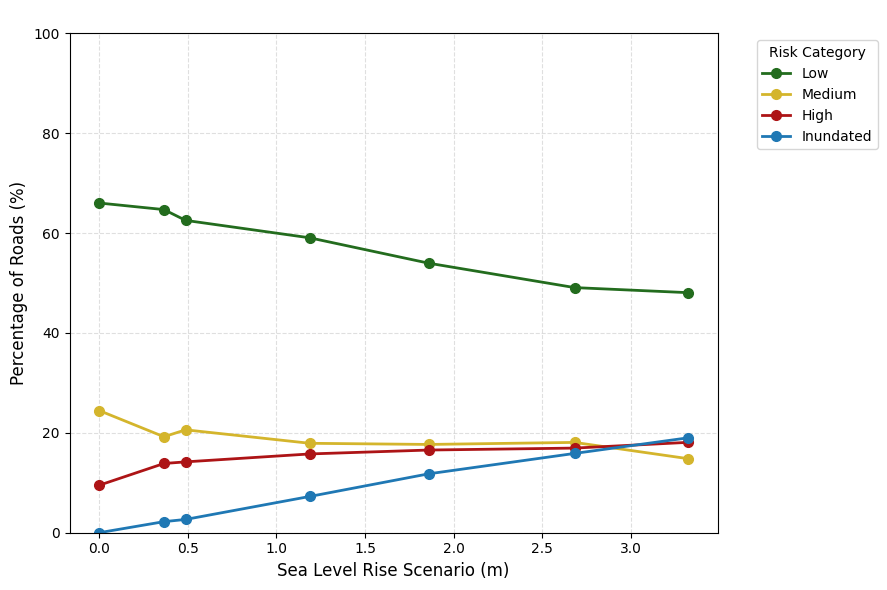

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load data
df = pd.read_csv("SLR_risk_summary.csv")

# Ensure expected columns
expected_cols = ["Scenario_ft", "Low", "Medium", "High", "Inundated"]
missing = [c for c in expected_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

# Convert feet to meters
df["Scenario_m"] = df["Scenario_ft"] * 0.3048  # 1 ft = 0.3048 m

df_pct = df.copy()
df_pct[["Low", "Medium", "High", "Inundated"]] = (
    df_pct[["Low", "Medium", "High", "Inundated"]]
    .div(df[["Low", "Medium", "High", "Inundated"]].sum(axis=1), axis=0)
    * 100
)

# Line chart setup with same colors as mapping
colors = {
    "Low": "#236c1e",
    "Medium": "#d4b52c",
    "High": "#ad1416",
    "Inundated": "#1f78b4"
}

categories = ["Low", "Medium", "High", "Inundated"]
x = df_pct["Scenario_m"]

fig, ax = plt.subplots(figsize=(9, 6))

# Plot lines and dots
for cat in categories:
    ax.plot(
        x,
        df_pct[cat],
        marker="o",
        color=colors[cat],
        label=cat,
        linewidth=2,
        markersize=7
    )

# Formatting shtuff
ax.set_xlabel("Sea Level Rise Scenario (m)", fontsize=12)
ax.set_ylabel("Percentage of Roads (%)", fontsize=12)
ax.set_title(" ", fontsize=14, weight="bold")

ax.legend(title="Risk Category", bbox_to_anchor=(1.05, 1), loc="upper left")
ax.set_ylim(0, 100)
ax.grid(axis="both", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

In [ ]:
#from google colab import file
#files.download('ME_roads_402m_coast_with_probs.csv')
#files.download("ME_roads_with_10.9ft_results.csv")
#files.download("ME_roads_with_8.8ft_results.csv")
#files.download("ME_roads_with_6.1ft_results.csv")
#files.download("ME_roads_with_3.9ft_results.csv")
#files.download("ME_roads_with_1.6ft_results.csv")
#files.download("ME_roads_with_1.2ft_results.csv")

# NH SLR Scenarios

Exploring a new approach with Wei, using only distance to the coast and elevation. Leaving out relative elevation.

## Maine Train Models

In [ ]:
# https://drive.google.com/file/d/1Q3nZD3b6yHmZkcsldsD8D8sF02uDrU6F/view?usp=sharing
!gdown 1Q3nZD3b6yHmZkcsldsD8D8sF02uDrU6F

Downloading...
From: https://drive.google.com/uc?id=1Q3nZD3b6yHmZkcsldsD8D8sF02uDrU6F
To: /content/ME_roads_all_info_with_structure.csv
100% 295k/295k [00:00<00:00, 3.90MB/s]


In [ ]:
import pandas as pd
import numpy as np
import joblib
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Load Maine subset
df = pd.read_csv("ME_roads_all_info_with_structure.csv")

# Keeping onyl distance to the coast and minimum elevation (leaving out relative elevation)
input_features = [
       'Distance_to_Coast_m', 'Z_Min'
]

target_column = 'Damage_Status'

# Change Damage and No Damage to binary
df[target_column] = df[target_column].map({'No Damage': 0, 'Damage': 1})
df = df.dropna(subset=[target_column])

# Split
damage_df = df[df[target_column] == 1]
nodamage_df = df[df[target_column] == 0]

print(f"Maine data -> Damage: {len(damage_df)} | No Damage: {len(nodamage_df)}")

# Separate numerical and categorical columns
numerical_cols = df[input_features].select_dtypes(include=np.number).columns
categorical_cols = df[input_features].select_dtypes(include='object').columns


# Preprocessor, no columns should be missing any data, just a precaution
preprocessor = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='mean'), numerical_cols),
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_cols)
    ],
    remainder='passthrough' # Keep other columns
)

# Train 100 Models
n_runs = 100 # number of runs

for run in range(n_runs):
    # 1:1 balanced sampling was found to be the best
    nodamage_sample = nodamage_df.sample(n=len(damage_df), random_state=run)
    balanced_df = pd.concat([damage_df, nodamage_sample], axis=0)

    X = balanced_df[input_features]
    y = balanced_df[target_column]

    # Train/test split (just to mimic structure, models will be saved after training)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=run
    )

    # Pipeline with Random Forest, the hyperparameters were tuned using grid search
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(
            random_state=run,
            n_estimators=400,
            max_depth=3,
            max_features='sqrt',
            bootstrap=True
        ))
    ])

    # Fit
    pipeline.fit(X_train, y_train)

    # Save models
    model_path = f"washout_model_run_{run}.pkl"
    joblib.dump(pipeline, model_path)

print(f"Done with {n_runs} models.")

Maine data -> Damage: 110 | No Damage: 496
Done with 100 models.


## Base (0 ft of SLR)

In [ ]:
# https://drive.google.com/file/d/1l8Mqnnr84JhhQuyGNumHGDct3dSB_R9W/view?usp=sharing
!gdown 1l8Mqnnr84JhhQuyGNumHGDct3dSB_R9W

Downloading...
From: https://drive.google.com/uc?id=1l8Mqnnr84JhhQuyGNumHGDct3dSB_R9W
To: /content/All NH Roads XYZ.csv
100% 728k/728k [00:00<00:00, 1.63MB/s]


In [ ]:
# https://drive.google.com/file/d/1uC8uUJGBahxT3SsYQeISASEiwIiIYgAw/view?usp=sharing
!gdown 1uC8uUJGBahxT3SsYQeISASEiwIiIYgAw

Downloading...
From: https://drive.google.com/uc?id=1uC8uUJGBahxT3SsYQeISASEiwIiIYgAw
To: /content/NH Coast.zip
100% 1.34M/1.34M [00:00<00:00, 9.52MB/s]


In [ ]:
import os
import zipfile
import pandas as pd
import geopandas as gpd
import numpy as np
import joblib
from shapely.geometry import Point
from tqdm import tqdm

# Set up
slr_scenario_ft = 0  # Scenario
slr_zip = "NH Coast.zip"  # ZIP containing NH MHHW shapefile
slr_extract = os.path.splitext(slr_zip)[0]  # Folder name without .zip
slr_shp_name = "NH Coast.shp"  # Inside the ZIP
n_runs = 100 # number of runs
utm_crs = "EPSG:26919"  # Maine/NH UTM 19N
base_csv = "All NH Roads XYZ.csv"
output_csv = f"NH_roads_with_{slr_scenario_ft}ft_results.csv"

# Load road data
roads_df = pd.read_csv(base_csv)

geometry = [Point(xy) for xy in zip(roads_df["x"], roads_df["y"])]
roads_gdf = gpd.GeoDataFrame(roads_df, geometry=geometry, crs="EPSG:4326").to_crs(utm_crs)

# Load and project the Coastline shapefile

if not os.path.exists(slr_extract):
    with zipfile.ZipFile(slr_zip, "r") as zip_ref:
        zip_ref.extractall(slr_extract)

# Find "NH Coast.shp" inside the extracted folder
slr_path = None
for root, _, files in os.walk(slr_extract):
    for f in files:
        if f == slr_shp_name:
            slr_path = os.path.join(root, f)
            break
    if slr_path:
        break

if slr_path is None:
    raise FileNotFoundError(f"Could not find '{slr_shp_name}' inside '{slr_extract}'")

print(f"Found shapefile: {slr_path}")
slr_gdf = gpd.read_file(slr_path).to_crs(utm_crs)

# Base scenario: no inundation
roads_gdf["Inundated"] = False

# Calculate distance from each point to the coast polygon
roads_gdf["Distance_to_Coast_m"] = roads_gdf.geometry.apply(lambda pt: slr_gdf.distance(pt).min())

# Apply trained Random Forest models
input_features = ["Z_Min", "Distance_to_Coast_m"]

X = roads_gdf[input_features].copy()
X["Distance_to_Coast_m"] = X["Distance_to_Coast_m"].fillna(X["Distance_to_Coast_m"].max())

probabilities = []

for run in tqdm(range(n_runs)):
    model_path = f"washout_model_run_{run}.pkl"
    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Model file not found: {model_path}")
    model = joblib.load(model_path)
    probs = model.predict_proba(X)[:, 1]
    probabilities.append(probs)

avg_prob = np.mean(np.column_stack(probabilities), axis=1)

# Assign washout probabilities
roads_gdf["Washout_Probability"] = avg_prob
roads_gdf.loc[roads_gdf["Inundated"], "Washout_Probability"] = -0.1  # mark inundated, this marking is for mapping purposes

# Save results
roads_gdf.drop(columns="geometry").to_csv(output_csv, index=False)

print(f"\nFinished processing for {slr_scenario_ft} ft SLR.")
print(f"Results saved to: {output_csv}")
print(roads_gdf[["OBJECTID", "Inundated", "Distance_to_Coast_m", "Washout_Probability"]].head())

Found shapefile: NH Coast/NH Coast/NH Coast.shp


100%|██████████| 100/100 [00:15<00:00,  6.38it/s]


Finished processing for 0 ft SLR.
Results saved to: NH_roads_with_0ft_results.csv
   OBJECTID  Inundated  Distance_to_Coast_m  Washout_Probability
0     23339      False            36.569490             0.735472
1     23340      False            86.539864             0.645498
2     23341      False            99.396571             0.615635
3     23342      False           128.239685             0.631187
4     23343      False           164.576479             0.676810


## 1 ft (0.3 m) of SLR

In [ ]:
# https://drive.google.com/file/d/1h0jbU-tGopaCQKOFyzlYfLewZhFrPimr/view?usp=sharing
!gdown 1h0jbU-tGopaCQKOFyzlYfLewZhFrPimr

Downloading...
From (original): https://drive.google.com/uc?id=1h0jbU-tGopaCQKOFyzlYfLewZhFrPimr
From (redirected): https://drive.google.com/uc?id=1h0jbU-tGopaCQKOFyzlYfLewZhFrPimr&confirm=t&uuid=278f247f-5dbe-4198-9870-1c2395570856
To: /content/NH_Sea_Level_Rise_(2023)_-_MHHW_plus_1ft_SLR.zip
100% 37.2M/37.2M [00:01<00:00, 20.1MB/s]


In [ ]:
import os
import zipfile
import pandas as pd
import geopandas as gpd
import numpy as np
import joblib
from shapely.geometry import Point
from tqdm import tqdm

# Set up
slr_scenario_ft = 1  # SLR scenario
slr_zip = "NH_Sea_Level_Rise_(2023)_-_MHHW_plus_1ft_SLR.zip"  # ZIP containing shapefile
slr_extract = os.path.splitext(slr_zip)[0]
slr_shp_name = "NH_Sea_Level_Rise_(2023)_-_MHHW_plus_1ft_SLR.shp"  # Inside the ZIP
utm_crs = "EPSG:26919"  # NAD83 / UTM zone 19N (NH + ME)
base_csv = "All NH Roads XYZ.csv"
output_csv = f"NH_roads_with_{slr_scenario_ft}ft_results.csv"

n_runs = 100 # Number of runs
model_prefix = "washout_model_run_"  # Maine trained models

# Load NH road data
roads_df = pd.read_csv(base_csv)

# 'x' and 'y' in decimal degrees
geometry = [Point(xy) for xy in zip(roads_df["x"], roads_df["y"])]
roads_gdf = gpd.GeoDataFrame(roads_df, geometry=geometry, crs="EPSG:4326").to_crs(utm_crs)

# Load SLR shapefile
if not os.path.exists(slr_extract):
    with zipfile.ZipFile(slr_zip, "r") as zip_ref:
        zip_ref.extractall(slr_extract)

slr_path = None
for root, _, files in os.walk(slr_extract):
    for f in files:
        if f == slr_shp_name:
            slr_path = os.path.join(root, f)
            break
    if slr_path:
        break

if slr_path is None:
    raise FileNotFoundError(f"Could not find '{slr_shp_name}' inside '{slr_extract}'")

print(f"Found shapefile: {slr_path}")
slr_gdf = gpd.read_file(slr_path).to_crs(utm_crs)

# Identify inundated roads and calculate distance

# Identify inundated roads (inside SLR polygon)
roads_gdf["Inundated"] = roads_gdf.geometry.apply(
    lambda pt: slr_gdf.contains(pt).any()
)

# Calculate distance to inundation polygon boundary
roads_gdf["Distance_to_Coast_m"] = roads_gdf.geometry.apply(
    lambda pt: slr_gdf.distance(pt).min()
)

# Adjust elevation (Z_Min) for SLR (in meters)
slr_scenario_m = slr_scenario_ft * 0.3048
roads_gdf["Z_Min_original"] = roads_gdf["Z_Min"]
roads_gdf["Z_Min"] = roads_gdf["Z_Min"] - slr_scenario_m


# Apply Maine-trained Random Forest models
input_features = [
    "Z_Min", "Distance_to_Coast_m",
]

# Drop missing features
missing_feats = [f for f in input_features if f not in roads_gdf.columns]
if missing_feats:
    print(f"Missing features in input data: {missing_feats}")

X = roads_gdf[[f for f in input_features if f in roads_gdf.columns]].copy()
X["Distance_to_Coast_m"] = X["Distance_to_Coast_m"].fillna(X["Distance_to_Coast_m"].max())

probabilities = []
for run in tqdm(range(n_runs), desc="Model runs"):
    model_path = f"{model_prefix}{run}.pkl"
    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Model file not found: {model_path}")
    model = joblib.load(model_path)
    probs = model.predict_proba(X)[:, 1]
    probabilities.append(probs)

avg_prob = np.mean(np.column_stack(probabilities), axis=1)

# Assign washout probabilities
roads_gdf["Washout_Probability"] = avg_prob
roads_gdf.loc[roads_gdf["Inundated"], "Washout_Probability"] = -0.1  # Mark inundated roads for mapping

# Save results
roads_gdf.drop(columns="geometry").to_csv(output_csv, index=False)

print(f"\n Finished processing {slr_scenario_ft} ft SLR scenario.")
print(f"Results saved to: {output_csv}")

print(roads_gdf[["OBJECTID", "Inundated", "Distance_to_Coast_m", "Z_Min", "Washout_Probability"]].head())

Found shapefile: NH_Sea_Level_Rise_(2023)_-_MHHW_plus_1ft_SLR/NH_Sea_Level_Rise_(2023)_-_MHHW_plus_1ft_SLR.shp


Model runs: 100%|██████████| 100/100 [00:15<00:00,  6.35it/s]



 Finished processing 1 ft SLR scenario.
Results saved to: NH_roads_with_1ft_results.csv
   OBJECTID  Inundated  Distance_to_Coast_m     Z_Min  Washout_Probability
0     23339      False            35.432825  1.400987             0.742003
1     23340      False            30.919588  1.457976             0.759790
2     23341      False            35.659585  1.475512             0.744365
3     23342      False            40.929187  1.572086             0.703942
4     23343      False            47.214252  1.646896             0.684741


## 2 ft (0.6 m) of SLR

In [ ]:
# https://drive.google.com/file/d/1l_dhejIeuXgJDaVH-y1oF6PwMpUhpvHg/view?usp=sharing
!gdown 1l_dhejIeuXgJDaVH-y1oF6PwMpUhpvHg

Downloading...
From (original): https://drive.google.com/uc?id=1l_dhejIeuXgJDaVH-y1oF6PwMpUhpvHg
From (redirected): https://drive.google.com/uc?id=1l_dhejIeuXgJDaVH-y1oF6PwMpUhpvHg&confirm=t&uuid=cf1a891e-c9d4-4e5d-96e5-be952cc6b5fa
To: /content/NH_Sea_Level_Rise_(2023)_-_MHHW_plus_2ft_SLR.zip
100% 40.0M/40.0M [00:00<00:00, 40.3MB/s]


In [ ]:
import os
import zipfile
import pandas as pd
import geopandas as gpd
import numpy as np
import joblib
from shapely.geometry import Point
from tqdm import tqdm

# Set up
slr_scenario_ft = 2  # SLR scenario
slr_zip = "NH_Sea_Level_Rise_(2023)_-_MHHW_plus_2ft_SLR.zip"  # ZIP containing shapefile
slr_extract = os.path.splitext(slr_zip)[0]
slr_shp_name = "NH_Sea_Level_Rise_(2023)_-_MHHW_plus_2ft_SLR.shp"  # Inside the ZIP
utm_crs = "EPSG:26919"  # NAD83 / UTM zone 19N (NH + ME)
base_csv = "All NH Roads XYZ.csv"
output_csv = f"NH_roads_with_{slr_scenario_ft}ft_results.csv"

n_runs = 100 # Number of runs
model_prefix = "washout_model_run_"  # Maine trained models

# Load NH road data
roads_df = pd.read_csv(base_csv)

# 'x' and 'y' in decimal degrees
geometry = [Point(xy) for xy in zip(roads_df["x"], roads_df["y"])]
roads_gdf = gpd.GeoDataFrame(roads_df, geometry=geometry, crs="EPSG:4326").to_crs(utm_crs)

# Load SLR shapefile
if not os.path.exists(slr_extract):
    with zipfile.ZipFile(slr_zip, "r") as zip_ref:
        zip_ref.extractall(slr_extract)

slr_path = None
for root, _, files in os.walk(slr_extract):
    for f in files:
        if f == slr_shp_name:
            slr_path = os.path.join(root, f)
            break
    if slr_path:
        break

if slr_path is None:
    raise FileNotFoundError(f"Could not find '{slr_shp_name}' inside '{slr_extract}'")

print(f"Found shapefile: {slr_path}")
slr_gdf = gpd.read_file(slr_path).to_crs(utm_crs)

# Identify inundated roads and calculate distance
# Identify inundated roads (inside SLR polygon)
roads_gdf["Inundated"] = roads_gdf.geometry.apply(
    lambda pt: slr_gdf.contains(pt).any()
)

# Calculate distance to inundation polygon boundary
roads_gdf["Distance_to_Coast_m"] = roads_gdf.geometry.apply(
    lambda pt: slr_gdf.distance(pt).min()
)

# Adjust elevation (Z_Min) for SLR (in meters)
slr_scenario_m = slr_scenario_ft * 0.3048
roads_gdf["Z_Min_original"] = roads_gdf["Z_Min"]
roads_gdf["Z_Min"] = roads_gdf["Z_Min"] - slr_scenario_m


# Apply Maine-trained Random Forest models
input_features = [
    "Z_Min", "Distance_to_Coast_m",
]

# Drop missing features
missing_feats = [f for f in input_features if f not in roads_gdf.columns]
if missing_feats:
    print(f"Missing features in input data: {missing_feats}")

X = roads_gdf[[f for f in input_features if f in roads_gdf.columns]].copy()
X["Distance_to_Coast_m"] = X["Distance_to_Coast_m"].fillna(X["Distance_to_Coast_m"].max())

probabilities = []
for run in tqdm(range(n_runs), desc="Model runs"):
    model_path = f"{model_prefix}{run}.pkl"
    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Model file not found: {model_path}")
    model = joblib.load(model_path)
    probs = model.predict_proba(X)[:, 1]
    probabilities.append(probs)

avg_prob = np.mean(np.column_stack(probabilities), axis=1)

# Assign washout probabilities
roads_gdf["Washout_Probability"] = avg_prob
roads_gdf.loc[roads_gdf["Inundated"], "Washout_Probability"] = -0.1  # Mark inundated roads for mapping

# Save results
roads_gdf.drop(columns="geometry").to_csv(output_csv, index=False)

print(f"\n Finished processing {slr_scenario_ft} ft SLR scenario.")
print(f"Results saved to: {output_csv}")

print(roads_gdf[["OBJECTID", "Inundated", "Distance_to_Coast_m", "Z_Min", "Washout_Probability"]].head())

Found shapefile: NH_Sea_Level_Rise_(2023)_-_MHHW_plus_2ft_SLR/NH_Sea_Level_Rise_(2023)_-_MHHW_plus_2ft_SLR.shp


Model runs: 100%|██████████| 100/100 [00:15<00:00,  6.40it/s]



 Finished processing 2 ft SLR scenario.
Results saved to: NH_roads_with_2ft_results.csv
   OBJECTID  Inundated  Distance_to_Coast_m     Z_Min  Washout_Probability
0     23339      False            34.592934  1.096187             0.746512
1     23340       True             0.000000  1.153176            -0.100000
2     23341       True             0.000000  1.170712            -0.100000
3     23342      False             2.305683  1.267286             0.715164
4     23343      False             4.566428  1.342096             0.782199


## 4 ft (1.2 m) of SLR

In [ ]:
# https://drive.google.com/file/d/1hsfzoH7Qip_UciGv-xHV3_6bwa8ckfvN/view?usp=sharing
!gdown 1hsfzoH7Qip_UciGv-xHV3_6bwa8ckfvN

Downloading...
From (original): https://drive.google.com/uc?id=1hsfzoH7Qip_UciGv-xHV3_6bwa8ckfvN
From (redirected): https://drive.google.com/uc?id=1hsfzoH7Qip_UciGv-xHV3_6bwa8ckfvN&confirm=t&uuid=f185c9bd-dd16-4cdd-9889-90a1721e0322
To: /content/NH_Sea_Level_Rise_(2023)_-_MHHW_plus_4ft_SLR.zip
100% 48.7M/48.7M [00:02<00:00, 21.8MB/s]


In [ ]:
import os
import zipfile
import pandas as pd
import geopandas as gpd
import numpy as np
import joblib
from shapely.geometry import Point
from tqdm import tqdm

# Set up
slr_scenario_ft = 4  # SLR scenario in ft
slr_zip = "NH_Sea_Level_Rise_(2023)_-_MHHW_plus_4ft_SLR.zip"  # ZIP containing shapefile
slr_extract = os.path.splitext(slr_zip)[0]
slr_shp_name = "NH_Sea_Level_Rise_(2023)_-_MHHW_plus_4ft_SLR.shp"  # Inside the ZIP
utm_crs = "EPSG:26919"  # NAD83 / UTM zone 19N (NH + ME)
base_csv = "All NH Roads XYZ.csv"
output_csv = f"NH_roads_with_{slr_scenario_ft}ft_results.csv"

n_runs = 100 # Number of runs
model_prefix = "washout_model_run_"  # Maine trained models

# Load NH road data
roads_df = pd.read_csv(base_csv)

# 'x' and 'y' in decimal degrees
geometry = [Point(xy) for xy in zip(roads_df["x"], roads_df["y"])]
roads_gdf = gpd.GeoDataFrame(roads_df, geometry=geometry, crs="EPSG:4326").to_crs(utm_crs)

# Load SLR shapefile
if not os.path.exists(slr_extract):
    with zipfile.ZipFile(slr_zip, "r") as zip_ref:
        zip_ref.extractall(slr_extract)

slr_path = None
for root, _, files in os.walk(slr_extract):
    for f in files:
        if f == slr_shp_name:
            slr_path = os.path.join(root, f)
            break
    if slr_path:
        break

if slr_path is None:
    raise FileNotFoundError(f"Could not find '{slr_shp_name}' inside '{slr_extract}'")

print(f"Found shapefile: {slr_path}")
slr_gdf = gpd.read_file(slr_path).to_crs(utm_crs)

# Identify inundated roads and calculate distance
# Identify inundated roads (inside SLR polygon)
roads_gdf["Inundated"] = roads_gdf.geometry.apply(
    lambda pt: slr_gdf.contains(pt).any()
)

# Calculate distance to inundation polygon boundary
roads_gdf["Distance_to_Coast_m"] = roads_gdf.geometry.apply(
    lambda pt: slr_gdf.distance(pt).min()
)

# Adjust elevation (Z_Min) for SLR (in meters)
slr_scenario_m = slr_scenario_ft * 0.3048
roads_gdf["Z_Min_original"] = roads_gdf["Z_Min"]
roads_gdf["Z_Min"] = roads_gdf["Z_Min"] - slr_scenario_m


# Apply Maine-trained Random Forest models
input_features = [
    "Z_Min", "Distance_to_Coast_m",
]

# Drop missing features
missing_feats = [f for f in input_features if f not in roads_gdf.columns]
if missing_feats:
    print(f"Missing features in input data: {missing_feats}")

X = roads_gdf[[f for f in input_features if f in roads_gdf.columns]].copy()
X["Distance_to_Coast_m"] = X["Distance_to_Coast_m"].fillna(X["Distance_to_Coast_m"].max())

probabilities = []
for run in tqdm(range(n_runs), desc="Model runs"):
    model_path = f"{model_prefix}{run}.pkl"
    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Model file not found: {model_path}")
    model = joblib.load(model_path)
    probs = model.predict_proba(X)[:, 1]
    probabilities.append(probs)

avg_prob = np.mean(np.column_stack(probabilities), axis=1)

# Assign washout probabilities
roads_gdf["Washout_Probability"] = avg_prob
roads_gdf.loc[roads_gdf["Inundated"], "Washout_Probability"] = -0.1  # Mark inundated roads for mapping

# Save results
roads_gdf.drop(columns="geometry").to_csv(output_csv, index=False)

print(f"\n Finished processing {slr_scenario_ft} ft SLR scenario.")
print(f"Results saved to: {output_csv}")

print(roads_gdf[["OBJECTID", "Inundated", "Distance_to_Coast_m", "Z_Min", "Washout_Probability"]].head())

Found shapefile: NH_Sea_Level_Rise_(2023)_-_MHHW_plus_4ft_SLR/NH_Sea_Level_Rise_(2023)_-_MHHW_plus_4ft_SLR.shp


Model runs: 100%|██████████| 100/100 [00:16<00:00,  5.95it/s]



 Finished processing 4 ft SLR scenario.
Results saved to: NH_roads_with_4ft_results.csv
   OBJECTID  Inundated  Distance_to_Coast_m     Z_Min  Washout_Probability
0     23339       True                  0.0  0.486587                 -0.1
1     23340       True                  0.0  0.543576                 -0.1
2     23341       True                  0.0  0.561112                 -0.1
3     23342       True                  0.0  0.657686                 -0.1
4     23343       True                  0.0  0.732496                 -0.1


## 6 ft (1.8 m) of SLR

In [ ]:
# https://drive.google.com/file/d/10ij-X-0igJLbFeV9HS6foQNUaCYRJn5G/view?usp=sharing
!gdown 10ij-X-0igJLbFeV9HS6foQNUaCYRJn5G

Downloading...
From (original): https://drive.google.com/uc?id=10ij-X-0igJLbFeV9HS6foQNUaCYRJn5G
From (redirected): https://drive.google.com/uc?id=10ij-X-0igJLbFeV9HS6foQNUaCYRJn5G&confirm=t&uuid=d16ad3f4-3fea-4eb4-b15b-68997e93fb37
To: /content/NH_Sea_Level_Rise_(2023)_-_MHHW_plus_6ft_SLR.zip
100% 56.6M/56.6M [00:01<00:00, 52.2MB/s]


In [ ]:
import os
import zipfile
import pandas as pd
import geopandas as gpd
import numpy as np
import joblib
from shapely.geometry import Point
from tqdm import tqdm

# Set up
slr_scenario_ft = 6  # SLR scenario in ft
slr_zip = "NH_Sea_Level_Rise_(2023)_-_MHHW_plus_6ft_SLR.zip"  # ZIP containing shapefile
slr_extract = os.path.splitext(slr_zip)[0]
slr_shp_name = "NH_Sea_Level_Rise_(2023)_-_MHHW_plus_6ft_SLR.shp"  # Inside the ZIP
utm_crs = "EPSG:26919"  # NAD83 / UTM zone 19N (NH + ME)
base_csv = "All NH Roads XYZ.csv"
output_csv = f"NH_roads_with_{slr_scenario_ft}ft_results.csv"

n_runs = 100 # Number of runs
model_prefix = "washout_model_run_"  # Maine trained models

# Load NH road data
roads_df = pd.read_csv(base_csv)

# 'x' and 'y' in decimal degrees
geometry = [Point(xy) for xy in zip(roads_df["x"], roads_df["y"])]
roads_gdf = gpd.GeoDataFrame(roads_df, geometry=geometry, crs="EPSG:4326").to_crs(utm_crs)

# Load SLR shapefile
if not os.path.exists(slr_extract):
    with zipfile.ZipFile(slr_zip, "r") as zip_ref:
        zip_ref.extractall(slr_extract)

slr_path = None
for root, _, files in os.walk(slr_extract):
    for f in files:
        if f == slr_shp_name:
            slr_path = os.path.join(root, f)
            break
    if slr_path:
        break

if slr_path is None:
    raise FileNotFoundError(f"Could not find '{slr_shp_name}' inside '{slr_extract}'")

print(f"Found shapefile: {slr_path}")
slr_gdf = gpd.read_file(slr_path).to_crs(utm_crs)

# Identify inundated roads and calculate distance
# Identify inundated roads (inside SLR polygon)
roads_gdf["Inundated"] = roads_gdf.geometry.apply(
    lambda pt: slr_gdf.contains(pt).any()
)

# Calculate distance to inundation polygon boundary
roads_gdf["Distance_to_Coast_m"] = roads_gdf.geometry.apply(
    lambda pt: slr_gdf.distance(pt).min()
)

# Adjust elevation (Z_Min) for SLR (in meters)
slr_scenario_m = slr_scenario_ft * 0.3048
roads_gdf["Z_Min_original"] = roads_gdf["Z_Min"]
roads_gdf["Z_Min"] = roads_gdf["Z_Min"] - slr_scenario_m


# Apply Maine-trained Random Forest models
input_features = [
    "Z_Min", "Distance_to_Coast_m",
]

# Drop missing features
missing_feats = [f for f in input_features if f not in roads_gdf.columns]
if missing_feats:
    print(f"Missing features in input data: {missing_feats}")

X = roads_gdf[[f for f in input_features if f in roads_gdf.columns]].copy()
X["Distance_to_Coast_m"] = X["Distance_to_Coast_m"].fillna(X["Distance_to_Coast_m"].max())

probabilities = []
for run in tqdm(range(n_runs), desc="Model runs"):
    model_path = f"{model_prefix}{run}.pkl"
    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Model file not found: {model_path}")
    model = joblib.load(model_path)
    probs = model.predict_proba(X)[:, 1]
    probabilities.append(probs)

avg_prob = np.mean(np.column_stack(probabilities), axis=1)

# Assign washout probabilities
roads_gdf["Washout_Probability"] = avg_prob
roads_gdf.loc[roads_gdf["Inundated"], "Washout_Probability"] = -0.1  # Mark inundated roads for mapping

# Save results
roads_gdf.drop(columns="geometry").to_csv(output_csv, index=False)

print(f"\n Finished processing {slr_scenario_ft} ft SLR scenario.")
print(f"Results saved to: {output_csv}")

print(roads_gdf[["OBJECTID", "Inundated", "Distance_to_Coast_m", "Z_Min", "Washout_Probability"]].head())

Found shapefile: NH_Sea_Level_Rise_(2023)_-_MHHW_plus_6ft_SLR/NH_Sea_Level_Rise_(2023)_-_MHHW_plus_6ft_SLR.shp


Model runs: 100%|██████████| 100/100 [00:18<00:00,  5.44it/s]



 Finished processing 6 ft SLR scenario.
Results saved to: NH_roads_with_6ft_results.csv
   OBJECTID  Inundated  Distance_to_Coast_m     Z_Min  Washout_Probability
0     23339       True                  0.0 -0.123013                 -0.1
1     23340       True                  0.0 -0.066024                 -0.1
2     23341       True                  0.0 -0.048488                 -0.1
3     23342       True                  0.0  0.048086                 -0.1
4     23343       True                  0.0  0.122896                 -0.1


## 8 ft (2.4 m) of SLR

In [ ]:
# https://drive.google.com/file/d/1BzPjA0zT3RnLe5kdgezXJyRT_DpDrnmK/view?usp=sharing
!gdown 1BzPjA0zT3RnLe5kdgezXJyRT_DpDrnmK

Downloading...
From (original): https://drive.google.com/uc?id=1BzPjA0zT3RnLe5kdgezXJyRT_DpDrnmK
From (redirected): https://drive.google.com/uc?id=1BzPjA0zT3RnLe5kdgezXJyRT_DpDrnmK&confirm=t&uuid=9f7db3ff-e0c3-4004-a36f-339a9741bc86
To: /content/NH_Sea_Level_Rise_(2023)_-_MHHW_plus_8ft_SLR.zip
100% 65.0M/65.0M [00:01<00:00, 39.3MB/s]


In [ ]:
import os
import zipfile
import pandas as pd
import geopandas as gpd
import numpy as np
import joblib
from shapely.geometry import Point
from tqdm import tqdm

# Set up
slr_scenario_ft = 8  # SLR scenario in ft
slr_zip = "NH_Sea_Level_Rise_(2023)_-_MHHW_plus_8ft_SLR.zip"  # ZIP containing shapefile
slr_extract = os.path.splitext(slr_zip)[0]
slr_shp_name = "NH_Sea_Level_Rise_(2023)_-_MHHW_plus_8ft_SLR.shp"  # Inside the ZIP
utm_crs = "EPSG:26919"  # NAD83 / UTM zone 19N (NH + ME)
base_csv = "All NH Roads XYZ.csv"
output_csv = f"NH_roads_with_{slr_scenario_ft}ft_results.csv"

n_runs = 100 # Number of runs
model_prefix = "washout_model_run_"  # Maine trained models

# Load NH road data
roads_df = pd.read_csv(base_csv)

# 'x' and 'y' in decimal degrees
geometry = [Point(xy) for xy in zip(roads_df["x"], roads_df["y"])]
roads_gdf = gpd.GeoDataFrame(roads_df, geometry=geometry, crs="EPSG:4326").to_crs(utm_crs)

# Load SLR shapefile
if not os.path.exists(slr_extract):
    with zipfile.ZipFile(slr_zip, "r") as zip_ref:
        zip_ref.extractall(slr_extract)

slr_path = None
for root, _, files in os.walk(slr_extract):
    for f in files:
        if f == slr_shp_name:
            slr_path = os.path.join(root, f)
            break
    if slr_path:
        break

if slr_path is None:
    raise FileNotFoundError(f"Could not find '{slr_shp_name}' inside '{slr_extract}'")

print(f"Found shapefile: {slr_path}")
slr_gdf = gpd.read_file(slr_path).to_crs(utm_crs)

# Identify inundated roads and calculate distance
# Identify inundated roads (inside SLR polygon)
roads_gdf["Inundated"] = roads_gdf.geometry.apply(
    lambda pt: slr_gdf.contains(pt).any()
)

# Calculate distance to inundation polygon boundary
roads_gdf["Distance_to_Coast_m"] = roads_gdf.geometry.apply(
    lambda pt: slr_gdf.distance(pt).min()
)

# Adjust elevation (Z_Min) for SLR (in meters)
slr_scenario_m = slr_scenario_ft * 0.3048
roads_gdf["Z_Min_original"] = roads_gdf["Z_Min"]
roads_gdf["Z_Min"] = roads_gdf["Z_Min"] - slr_scenario_m


# Apply Maine-trained Random Forest models
input_features = [
    "Z_Min", "Distance_to_Coast_m",
]

# Drop missing features
missing_feats = [f for f in input_features if f not in roads_gdf.columns]
if missing_feats:
    print(f"Missing features in input data: {missing_feats}")

X = roads_gdf[[f for f in input_features if f in roads_gdf.columns]].copy()
X["Distance_to_Coast_m"] = X["Distance_to_Coast_m"].fillna(X["Distance_to_Coast_m"].max())

probabilities = []
for run in tqdm(range(n_runs), desc="Model runs"):
    model_path = f"{model_prefix}{run}.pkl"
    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Model file not found: {model_path}")
    model = joblib.load(model_path)
    probs = model.predict_proba(X)[:, 1]
    probabilities.append(probs)

avg_prob = np.mean(np.column_stack(probabilities), axis=1)

# Assign washout probabilities
roads_gdf["Washout_Probability"] = avg_prob
roads_gdf.loc[roads_gdf["Inundated"], "Washout_Probability"] = -0.1  # Mark inundated roads for mapping

# Save results
roads_gdf.drop(columns="geometry").to_csv(output_csv, index=False)

print(f"\n Finished processing {slr_scenario_ft} ft SLR scenario.")
print(f"Results saved to: {output_csv}")

print(roads_gdf[["OBJECTID", "Inundated", "Distance_to_Coast_m", "Z_Min", "Washout_Probability"]].head())

Found shapefile: NH_Sea_Level_Rise_(2023)_-_MHHW_plus_8ft_SLR/NH_Sea_Level_Rise_(2023)_-_MHHW_plus_8ft_SLR.shp


Model runs: 100%|██████████| 100/100 [00:16<00:00,  5.96it/s]


 Finished processing 8 ft SLR scenario.
Results saved to: NH_roads_with_8ft_results.csv
   OBJECTID  Inundated  Distance_to_Coast_m     Z_Min  Washout_Probability
0     23339       True                  0.0 -0.732613                 -0.1
1     23340       True                  0.0 -0.675624                 -0.1
2     23341       True                  0.0 -0.658088                 -0.1
3     23342       True                  0.0 -0.561514                 -0.1
4     23343       True                  0.0 -0.486704                 -0.1


## Summary


In [ ]:
from google.colab import files
#files.download("NH_roads_with_1ft_results.csv")
#files.download("NH_roads_with_2ft_results.csv")
#files.download("NH_roads_with_4ft_results.csv")
#files.download("NH_roads_with_6ft_results.csv")
#files.download("NH_roads_with_8ft_results.csv")
#files.download("NH_roads_with_0ft_results.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# https://drive.google.com/file/d/1fnlM5I63zJwHmoliQ5Jqb6G16ELR-zgH/view?usp=sharing
! gdown 1fnlM5I63zJwHmoliQ5Jqb6G16ELR-zgH
#https://drive.google.com/file/d/1xVgchRXnQ0QV4odZ3k3XpUnCzVCRGfLA/view?usp=sharing
! gdown 1xVgchRXnQ0QV4odZ3k3XpUnCzVCRGfLA
#https://drive.google.com/file/d/1zdnMSB9iIorXO4z5rHkrqFrma7s3FJ08/view?usp=sharing
! gdown 1zdnMSB9iIorXO4z5rHkrqFrma7s3FJ08
#https://drive.google.com/file/d/1qj-xmxL-4R2pZ7FDEwgw8Os_BzH9aYJJ/view?usp=sharing
! gdown 1qj-xmxL-4R2pZ7FDEwgw8Os_BzH9aYJJ
#https://drive.google.com/file/d/13nrBeFBDyWyth8nXbQhk7c0F4eQdJwiU/view?usp=sharing
! gdown 13nrBeFBDyWyth8nXbQhk7c0F4eQdJwiU
#https://drive.google.com/file/d/1VGLM0pcdBVjedoYeGskFvo78X8Tnm6AY/view?usp=sharing
! gdown 1VGLM0pcdBVjedoYeGskFvo78X8Tnm6AY

Downloading...
From: https://drive.google.com/uc?id=1fnlM5I63zJwHmoliQ5Jqb6G16ELR-zgH
To: /content/NH_roads_with_0ft_results.csv
100% 811k/811k [00:00<00:00, 7.27MB/s]
Downloading...
From: https://drive.google.com/uc?id=1xVgchRXnQ0QV4odZ3k3XpUnCzVCRGfLA
To: /content/NH_roads_with_1ft_results.csv
100% 814k/814k [00:00<00:00, 3.81MB/s]
Downloading...
From: https://drive.google.com/uc?id=1zdnMSB9iIorXO4z5rHkrqFrma7s3FJ08
To: /content/NH_roads_with_2ft_results.csv
100% 812k/812k [00:00<00:00, 4.89MB/s]
Downloading...
From: https://drive.google.com/uc?id=1qj-xmxL-4R2pZ7FDEwgw8Os_BzH9aYJJ
To: /content/NH_roads_with_4ft_results.csv
100% 807k/807k [00:00<00:00, 4.02MB/s]
Downloading...
From: https://drive.google.com/uc?id=13nrBeFBDyWyth8nXbQhk7c0F4eQdJwiU
To: /content/NH_roads_with_6ft_results.csv
100% 803k/803k [00:00<00:00, 8.45MB/s]
Downloading...
From: https://drive.google.com/uc?id=1VGLM0pcdBVjedoYeGskFvo78X8Tnm6AY
To: /content/NH_roads_with_8ft_results.csv
100% 798k/798k [00:00<00:00, 3.


Percentage of Roads by Risk Category and SLR Scenario:

      Low    Medium      High  Inundated  Scenario_ft  Scenario_m
25.272727 54.303030 16.606061   0.000000            0      0.0000
22.424242 47.393939 26.060606   2.121212            1      0.3048
20.363636 42.060606 30.000000   5.818182            2      0.6096
16.606061 34.121212 29.757576  18.484848            4      1.2192
12.848485 26.909091 26.666667  32.909091            6      1.8288
 9.939394 21.878788 22.969697  44.606061            8      2.4384


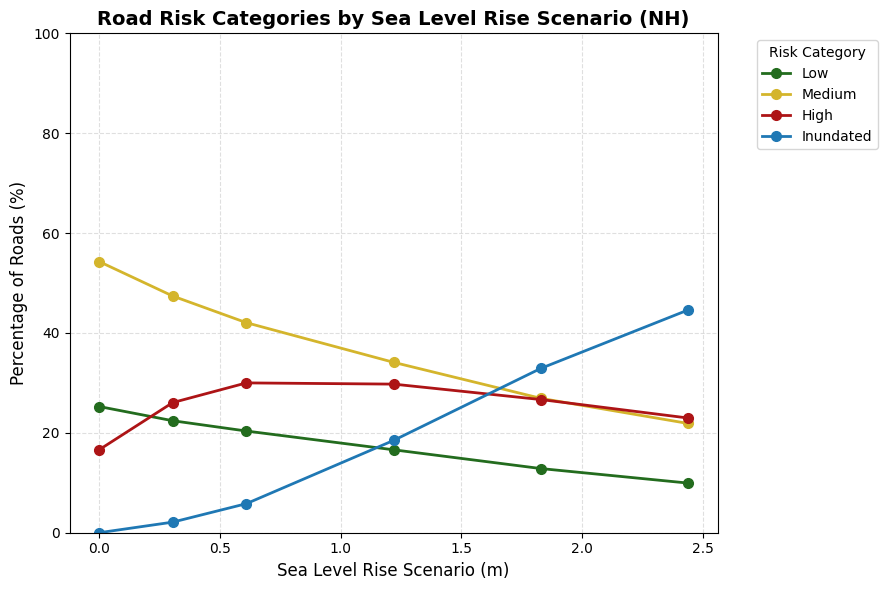

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Download files, if no already loaded
scenario_files = {
    0: "NH_roads_with_0ft_results.csv",
    1: "NH_roads_with_1ft_results.csv",
    2: "NH_roads_with_2ft_results.csv",
    4: "NH_roads_with_4ft_results.csv",
    6: "NH_roads_with_6ft_results.csv",
    8: "NH_roads_with_8ft_results.csv"
}

risk_bins = {
    "Low": (0, 0.33),
    "Medium": (0.34, 0.66),
    "High": (0.67, 1.0),
    "Inundated": (-0.11, -0.09)  # represent -0.1 as inundated for mapping
}

colors = {
    "Low": "#236c1e", # These are the same colors used in mapping
    "Medium": "#d4b52c",
    "High": "#ad1416",
    "Inundated": "#1f78b4"
}


# Calculated category percentages per scenario
summary = []

for slr_ft, file in scenario_files.items():
    df = pd.read_csv(file)
    total = len(df)
    counts = {}
    for cat, (low, high) in risk_bins.items():
        counts[cat] = ((df["Washout_Probability"] >= low) & (df["Washout_Probability"] <= high)).sum()
    percentages = {cat: (counts[cat] / total) * 100 for cat in risk_bins.keys()}
    percentages["Scenario_ft"] = slr_ft
    summary.append(percentages)

df_pct = pd.DataFrame(summary).sort_values("Scenario_ft")

# Convert feet to meters
df_pct["Scenario_m"] = df_pct["Scenario_ft"] * 0.3048  # 1 ft = 0.3048 m

# Display table in console
print("\nPercentage of Roads by Risk Category and SLR Scenario:\n")
print(df_pct.to_string(index=False))
df_pct.to_csv("NH_SLR_risk_summary.csv", index=False)

#  Save the table so don't have to us all the files everytime
df_pct.to_csv("NH_SLR_risk_summary.csv", index=False)

# Chart setup
categories = ["Low", "Medium", "High", "Inundated"]
x = df_pct["Scenario_m"]

fig, ax = plt.subplots(figsize=(9, 6))

# Plot dots connected by lines
for cat in categories:
    ax.plot(
        x,
        df_pct[cat],
        marker="o",
        color=colors[cat],
        label=cat,
        linewidth=2,
        markersize=7
    )

# Chart formatting
ax.set_xlabel("Sea Level Rise Scenario (m)", fontsize=12)
ax.set_ylabel("Percentage of Roads (%)", fontsize=12)
ax.set_title("Road Risk Categories by Sea Level Rise Scenario (NH)", fontsize=14, weight="bold")
ax.legend(title="Risk Category", bbox_to_anchor=(1.05, 1), loc="upper left")
ax.set_ylim(0, 100)
ax.grid(axis="both", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

We had talked a little bit about how washout risk would change with elevations, this graph provdes a little bit of insight into that question.

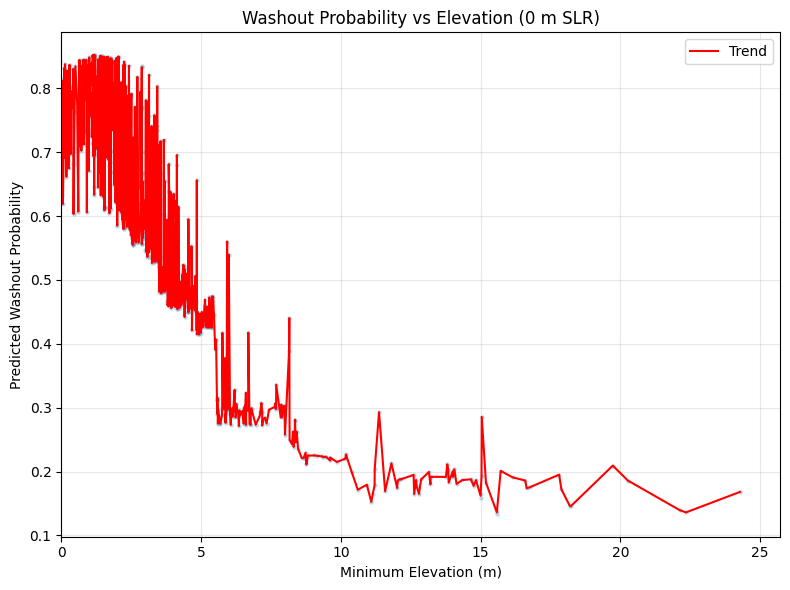

In [ ]:
# Some Visualization using baseline scenario (0 ft SLR)
import matplotlib.pyplot as plt
import seaborn as sns

# Load results
results_df = pd.read_csv(f"NH_roads_with_{slr_scenario_ft}ft_results.csv")

# Remove any rows marked as inundated (-0.1 means "inundated for mapping only")
results_df = results_df[results_df["Washout_Probability"] >= 0]

# Washout Probability vs Elevation
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=results_df.sample(min(5000, len(results_df))),  # sample for speed/clarity
    x="Z_Min",
    y="Washout_Probability",
    alpha=0.3,
    s=10
)
sns.lineplot(
    data=results_df,
    x="Z_Min",
    y="Washout_Probability",
    color="red",
    label="Trend",
    errorbar=None
)
plt.title("Washout Probability vs Elevation (0 m SLR)")
plt.xlabel("Minimum Elevation (m)")
plt.ylabel("Predicted Washout Probability")
plt.grid(True, alpha=0.3)
plt.legend()

# Set x-axis to start at 0 m
plt.xlim(left=0)

plt.tight_layout()
plt.show()